# Exploratory Analysis: Scarcity in Cinema

**Thesis research question:** under what conditions does scarcity in cinema operate as a symbolic signal of artistic value and social distinction, rather than simply as a distribution or access constraint?

This notebook uses `data_final/top_movies_imdb_final.csv` to build the quantitative background for that question. The dataset can measure theatrical access scarcity through theater counts, rollout scale, expansion patterns, theatrical staying power, box office performance, ROI, genre, production source, and IMDb reception. It cannot directly observe every scarcity form in the thesis draft, such as festival-only access, sold-out special screenings, invitation-only premieres, streaming-window timing, or Oppenheimer's IMAX 70mm venue scarcity. Those limits are made explicit in the interpretation sections.

**Execution note:** this notebook was executed with the existing `data-science` conda environment because the base `python3` kernel on this machine does not include `pandas`, `seaborn`, and related EDA libraries.

The EDA follows four goals:

1. Check whether the final dataset is usable for scarcity analysis.
2. Construct transparent scarcity and release-strategy variables.
3. Compare scarcity with rating, box office performance, legs, ROI, genre, proxy market positioning, and time.
4. Locate Parasite and Oppenheimer in the dataset and state which research questions are answered, partially answered, or not answered by this data alone.


In [1]:
import os
import warnings
from pathlib import Path

# Keep matplotlib cache outside the repo; useful on restricted machines.
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/movie_scarcity_mpl")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib.ticker import FuncFormatter, PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_PATH = PROJECT_ROOT / "data_final" / "top_movies_imdb_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

artifact_records = []

def rel(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def register_artifact(path, kind, description):
    artifact_records.append({
        "artifact": rel(path),
        "type": kind,
        "description": description,
    })

def save_figure(fig, name, description):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    register_artifact(path, "figure", description)
    print(f"Saved figure: {rel(path)}")
    return path

def save_table(table, name, description, index=False):
    csv_path = FIGURES_DIR / f"{name}.csv"
    html_path = FIGURES_DIR / f"{name}.html"
    table.to_csv(csv_path, index=index)
    table.to_html(html_path, index=index, border=0)
    register_artifact(csv_path, "table_csv", description)
    register_artifact(html_path, "table_html", description)
    print(f"Saved table: {rel(csv_path)}")
    print(f"Saved table: {rel(html_path)}")
    return table

def usd_millions(x, pos=None):
    if pd.isna(x):
        return ""
    return f"${x / 1_000_000:,.0f}M"

def compact_usd(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000_000:
        return f"${x / 1_000_000_000:,.2f}B"
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x / 1_000:,.1f}K"
    return f"${x:,.0f}"

def pct_mean(s):
    return float(s.mean() * 100)

release_order = [
    "Exclusive (1-10)",
    "Limited (11-100)",
    "Platform / moderate (101-600)",
    "Semi-wide (601-1,999)",
    "Wide (2,000+)",
]

strategy_palette = dict(zip(release_order, sns.color_palette("Set2", n_colors=len(release_order))))

raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {rel(DATA_PATH)}")
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")
display(raw.head())


Loaded: data_final/top_movies_imdb_final.csv
Rows: 3,959
Columns: 40


,movie_name,release_date,production_budget_usd,domestic_gross_usd,worldwide_gross_usd,domestic_box_office_usd,international_box_office_usd,worldwide_box_office_usd,opening_weekend_usd,legs,infl_adj_dom_bo_usd,mpaa_rating,running_time_minutes,source,genre,production_method,creative_type,domestic_share_percentage,release_year,release_month,release_quarter,opening_theaters,max_theaters,avg_weeks_per_theater,is_franchise,profit_worldwide,profit_domestic,roi_worldwide,roi_domestic,log_domestic_box_office,log_worldwide_box_office,log_budget,log_opening_weekend,log_opening_theaters,log_max_theaters,imdb_id,imdb_rating,imdb_votes,imdb_rating_num,imdb_votes_num
0,Avatar: The Way of Water,2022-12-09,460000000,684075767,2315589775,"684,075,767.00","1,631,514,008.00","2,315,589,775.00","134,100,226.00",5.10,"693,596,368.00",PG-13,190.00,Original Screenplay,Action,"Animation,Live Action",Science Fiction,29.50,"2,022.00",12.00,4.00,"4,202.00","4,340.00",11.10,1,"1,855,589,775.00","224,075,767.00",5.03,1.49,20.34,21.56,19.95,18.71,8.34,8.38,tt1630029,7.50,"601,100",7.50,"601,100.00"
1,Indiana Jones and the Dial of Destiny,2023-06-28,402300000,174480468,383963057,"174,480,468.00","209,482,589.00","383,963,057.00","60,368,101.00",2.89,"174,480,468.00",PG-13,142.00,Original Screenplay,Adventure,Live Action,Historical Fiction,45.40,"2,023.00",6.00,2.00,"4,600.00","4,600.00",4.60,1,"-18,336,943.00","-227,819,532.00",0.95,0.43,18.98,19.77,19.81,17.92,8.43,8.43,tt1462764,6.50,"230,035",6.50,"230,035.00"
2,Avengers: Endgame,2019-04-23,400000000,858373000,2748242781,"858,373,000.00","1,889,869,781.00","2,748,242,781.00","357,115,007.00",2.40,"1,010,181,328.00",PG-13,181.00,Based on Comic/Graphic Novel,Action,"Animation,Live Action",Super Hero,31.20,"2,019.00",4.00,2.00,"4,662.00","4,662.00",8.10,1,"2,348,242,781.00","458,373,000.00",6.87,2.15,20.57,21.73,19.81,19.69,8.45,8.45,tt4154796,8.40,"1,442,446",8.40,"1,442,446.00"
3,Pirates of the Caribbean: On Stranger Tides,2011-05-20,379000000,241071802,1045713802,"241,071,802.00","804,642,000.00","1,045,713,802.00","90,151,958.00",2.67,"327,711,731.00",PG-13,136.00,Based on Theme Park Ride,Adventure,Live Action,Historical Fiction,23.10,"2,011.00",5.00,2.00,"4,155.00","4,164.00",6.00,1,"666,713,802.00","-137,928,198.00",2.76,0.64,19.30,20.77,19.75,18.32,8.33,8.33,tt1298650,6.60,"606,603",6.60,"606,603.00"
4,Avengers: Age of Ultron,2015-04-22,365000000,459005868,1395316979,"459,005,868.00","936,311,111.00","1,395,316,979.00","191,271,109.00",2.40,"586,961,233.00",PG-13,141.00,Based on Comic/Graphic Novel,Action,"Animation,Live Action",Super Hero,32.90,"2,015.00",4.00,2.00,"4,276.00","4,276.00",7.00,1,"1,030,316,979.00","94,005,868.00",3.82,1.26,19.94,21.06,19.72,19.07,8.36,8.36,tt2395427,7.30,"998,463",7.30,"998,463.00"


## 1. Data Quality EDA

This first section checks whether the final file is complete enough for release-scarcity analysis. The important variables are release date, theater counts, box office, budget, IMDb rating, IMDb votes, ROI, legs, genre, source, creative type, and franchise status.


In [2]:
df = raw.copy()

numeric_cols = [
    "production_budget_usd", "domestic_gross_usd", "worldwide_gross_usd",
    "domestic_box_office_usd", "international_box_office_usd", "worldwide_box_office_usd",
    "opening_weekend_usd", "legs", "infl_adj_dom_bo_usd", "running_time_minutes",
    "domestic_share_percentage", "release_year", "release_month", "release_quarter",
    "opening_theaters", "max_theaters", "avg_weeks_per_theater", "is_franchise",
    "profit_worldwide", "profit_domestic", "roi_worldwide", "roi_domestic",
    "log_domestic_box_office", "log_worldwide_box_office", "log_budget",
    "log_opening_weekend", "log_opening_theaters", "log_max_theaters",
    "imdb_rating_num", "imdb_votes_num",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
for col in ["release_year", "release_month", "release_quarter", "is_franchise"]:
    df[col] = df[col].astype("Int64")

column_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=False).values,
})

save_table(column_overview, "table_01_data_quality_columns", "Column-level missingness, dtypes, and unique-value counts.")
display(column_overview)


Saved table: figures/table_01_data_quality_columns.csv
Saved table: figures/table_01_data_quality_columns.html


,column,dtype,non_null,missing,missing_pct,unique_values
0,movie_name,str,3959,0,0.00,3915
1,release_date,datetime64[us],3959,0,0.00,2258
2,production_budget_usd,int64,3959,0,0.00,380
3,domestic_gross_usd,int64,3959,0,0.00,3959
4,worldwide_gross_usd,int64,3959,0,0.00,3957
5,domestic_box_office_usd,float64,3959,0,0.00,3959
6,international_box_office_usd,float64,3959,0,0.00,3845
7,worldwide_box_office_usd,float64,3959,0,0.00,3957
8,opening_weekend_usd,float64,3959,0,0.00,3958
9,legs,float64,3959,0,0.00,899


In [3]:
key_numeric = [
    "production_budget_usd", "opening_weekend_usd", "domestic_box_office_usd",
    "worldwide_box_office_usd", "opening_theaters", "max_theaters",
    "avg_weeks_per_theater", "legs", "roi_worldwide", "imdb_rating_num", "imdb_votes_num",
]

quality_flags = pd.DataFrame({
    "check": [
        "rows", "columns", "duplicate full rows", "duplicate movie_name + release_year",
        "minimum release year", "maximum release year", "missing release_date",
        "missing opening_theaters", "missing max_theaters", "missing IMDb rating",
    ],
    "value": [
        len(df), df.shape[1], int(df.duplicated().sum()), int(df.duplicated(["movie_name", "release_year"]).sum()),
        int(df["release_year"].min()), int(df["release_year"].max()), int(df["release_date"].isna().sum()),
        int(df["opening_theaters"].isna().sum()), int(df["max_theaters"].isna().sum()), int(df["imdb_rating_num"].isna().sum()),
    ]
})

numeric_summary = (
    df[key_numeric]
    .describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
    .round(2)
)

save_table(quality_flags, "table_02_data_quality_checks", "Dataset-level data quality checks for the EDA sample.")
save_table(numeric_summary, "table_03_numeric_summary", "Descriptive summary for the main numeric variables used in the scarcity EDA.")

display(quality_flags)
display(numeric_summary)


Saved table: figures/table_02_data_quality_checks.csv
Saved table: figures/table_02_data_quality_checks.html
Saved table: figures/table_03_numeric_summary.csv
Saved table: figures/table_03_numeric_summary.html


,check,value
0,rows,3959
1,columns,40
2,duplicate full rows,0
3,duplicate movie_name + release_year,0
4,minimum release year,1972
5,maximum release year,2025
6,missing release_date,0
7,missing opening_theaters,0
8,missing max_theaters,0
9,missing IMDb rating,98


,variable,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,production_budget_usd,"3,959.00","45,586,786.25","50,435,008.34","7,000.00","379,000.00","2,000,000.00","5,000,000.00","12,000,000.00","29,000,000.00","60,000,000.00","110,000,000.00","155,000,000.00","225,000,000.00","460,000,000.00"
1,opening_weekend_usd,"3,959.00","16,811,158.11","25,258,135.85",226.00,"8,860.54","39,312.50","90,834.40","1,583,077.50","9,724,200.00","20,565,576.00","40,232,720.60","60,103,593.30","133,819,325.92","357,115,007.00"
2,domestic_box_office_usd,"3,959.00","61,477,337.42","83,107,369.55",264.00,"29,838.46","537,948.40","2,283,737.40","12,179,317.00","35,017,297.00","75,664,679.50","150,357,368.80","213,515,303.80","408,465,676.66","858,373,000.00"
3,worldwide_box_office_usd,"3,959.00","140,363,730.62","219,851,085.23","26,822.00","235,499.50","1,884,151.50","5,945,867.60","21,144,785.00","63,356,133.00","164,657,901.50","355,719,445.40","549,681,400.10","1,056,499,262.28","2,923,706,026.00"
4,opening_theaters,"3,959.00","2,052.59","1,380.50",1.00,1.00,3.00,5.00,512.00,"2,445.00","3,104.50","3,681.20","4,007.00","4,349.00","4,735.00"
5,max_theaters,"3,959.00","2,250.77","1,235.11",1.00,9.58,52.90,180.00,"1,318.00","2,525.00","3,154.00","3,723.00","4,029.10","4,352.94","4,802.00"
6,avg_weeks_per_theater,"3,959.00",5.37,2.97,0.00,1.00,2.10,2.50,3.40,4.80,6.50,8.70,10.20,16.24,32.70
7,legs,"3,959.00",4.46,5.46,1.00,1.51,1.97,2.15,2.55,3.26,4.70,7.84,10.83,17.49,172.90
8,roi_worldwide,"3,959.00",4.54,15.04,0.01,0.04,0.25,0.49,1.11,2.34,4.32,8.07,12.35,37.66,431.52
9,imdb_rating_num,"3,861.00",6.47,0.97,1.50,3.66,4.80,5.30,5.90,6.50,7.10,7.60,7.90,8.40,9.70


**Data quality commentary.** The final CSV is complete for the core theatrical variables: opening theaters, maximum theaters, opening weekend, box office, budget, legs, and ROI. IMDb ratings are missing for a small subset of films, so rating-related charts drop those rows only where needed. The year range is broad, but the dataset is not a census of all theatrical releases; time-trend results should therefore be read as patterns within this top-movie sample.


## 2. Create Scarcity Variables

The thesis defines scarcity as more than low capacity. In this dataset, scarcity can be operationalized only through theatrical-release structure. The variables below separate three ideas:

- **Initial access scarcity:** how many theaters had the film at opening.
- **Expansion scarcity:** whether a film began scarce and then expanded after demand, awards buzz, or word of mouth.
- **Market positioning proxies:** whether the film looks closer to a platform/prestige model or a mainstream/event model using available variables.

The thresholds are descriptive, not universal industry laws. They are intentionally simple so the thesis can explain and critique them.


In [4]:
eda = df.copy()

# Clean a few categorical fields for more stable grouping.
eda["mpaa_rating_clean"] = (
    eda["mpaa_rating"].astype(str).str.extract(r"^(G|PG-13|PG|R|NC-17|Not Rated|Open)", expand=False)
    .fillna("Other / unclear")
)
eda["release_year"] = eda["release_year"].astype(int)
eda["release_month"] = eda["release_month"].astype(int)
eda["release_quarter"] = eda["release_quarter"].astype(int)
eda["is_franchise_bool"] = eda["is_franchise"].fillna(0).astype(int).eq(1)

# Main scarcity variables.
eda["log_opening_theaters_calc"] = np.log1p(eda["opening_theaters"])
eda["log_max_theaters_calc"] = np.log1p(eda["max_theaters"])
eda["opening_scarcity_score"] = 1 - eda["opening_theaters"].rank(pct=True, method="average")
eda["opening_scarcity_pct"] = eda["opening_scarcity_score"] * 100

eda["release_strategy"] = pd.cut(
    eda["opening_theaters"],
    bins=[0, 10, 100, 600, 1999, np.inf],
    labels=release_order,
    include_lowest=True,
    right=True,
)

eda["theater_expansion_ratio"] = np.where(
    eda["opening_theaters"] > 0,
    eda["max_theaters"] / eda["opening_theaters"],
    np.nan,
)
eda["opening_to_max_ratio"] = np.where(
    eda["max_theaters"] > 0,
    eda["opening_theaters"] / eda["max_theaters"],
    np.nan,
)
eda["log_expansion_ratio"] = np.log(eda["theater_expansion_ratio"].clip(lower=1))

eda["exclusive_opening_10"] = eda["opening_theaters"] <= 10
eda["limited_opening_100"] = eda["opening_theaters"] <= 100
eda["wide_opening_2000"] = eda["opening_theaters"] >= 2000
eda["platform_expansion_flag"] = (eda["opening_theaters"] <= 100) & (eda["max_theaters"] >= 1000)
eda["major_expansion_flag"] = (eda["theater_expansion_ratio"] >= 10) & (eda["max_theaters"] >= 1000)

eda["scarcity_quartile"] = pd.qcut(
    eda["opening_theaters"].rank(method="first"),
    q=4,
    labels=["Highest scarcity", "Higher-mid scarcity", "Lower-mid scarcity", "Lowest scarcity"],
)

budget_q75 = eda["production_budget_usd"].quantile(.75)
prestige_genres = {"Drama", "Black Comedy", "Documentary"}
prestige_creative = {"Dramatization", "Factual", "Historical Fiction", "Contemporary Fiction"}
prestige_sources = {
    "Original Screenplay", "Based on Fiction Book/Short Story", "Based on Real Life Events",
    "Based on Factual Book/Article", "Based on Play", "Based on Musical or Opera",
}
mainstream_genres = {"Action", "Adventure"}
mainstream_creative = {"Super Hero", "Science Fiction", "Fantasy", "Kids Fiction"}

eda["arthouse_prestige_proxy"] = (
    ~eda["is_franchise_bool"]
    & (eda["opening_theaters"] <= 600)
    & (
        eda["genre"].isin(prestige_genres)
        | eda["creative_type"].isin(prestige_creative)
        | eda["source"].isin(prestige_sources)
    )
    & (eda["production_budget_usd"] <= budget_q75)
)

eda["mainstream_event_proxy"] = (
    eda["is_franchise_bool"]
    | (eda["opening_theaters"] >= 2000)
    | (eda["production_budget_usd"] >= budget_q75)
    | eda["genre"].isin(mainstream_genres)
    | eda["creative_type"].isin(mainstream_creative)
)

eda["positioning_proxy"] = np.select(
    [eda["arthouse_prestige_proxy"], eda["mainstream_event_proxy"]],
    ["Arthouse/prestige proxy", "Mainstream/event proxy"],
    default="Other / mixed proxy",
)

variable_dictionary = pd.DataFrame([
    ["release_strategy", "Opening-theater bucket: exclusive, limited, platform/moderate, semi-wide, or wide."],
    ["opening_scarcity_score", "Percentile-style scarcity score from 0 to 1; higher means fewer opening theaters."],
    ["opening_scarcity_pct", "Same score on a 0-100 scale."],
    ["scarcity_quartile", "Quartiles of opening-theater scarcity, with highest scarcity meaning the smallest openings."],
    ["theater_expansion_ratio", "Maximum theaters divided by opening theaters; high values indicate platform-style expansion."],
    ["opening_to_max_ratio", "Opening theaters divided by maximum theaters; low values mean early access was much more restricted than later access."],
    ["platform_expansion_flag", "Opening in 100 or fewer theaters and eventually reaching at least 1,000 theaters."],
    ["major_expansion_flag", "At least 10x theater expansion and eventual maximum of at least 1,000 theaters."],
    ["arthouse_prestige_proxy", "Non-franchise, <=600 opening theaters, lower/moderate budget, and genre/source/creative markers associated with prestige cinema."],
    ["mainstream_event_proxy", "Franchise, wide opening, high budget, or action/adventure/fantasy/sci-fi/superhero/kids markers."],
])
variable_dictionary.columns = ["variable", "definition"]

save_table(variable_dictionary, "table_04_scarcity_variable_dictionary", "Definitions of constructed scarcity and positioning variables.")
display(variable_dictionary)


Saved table: figures/table_04_scarcity_variable_dictionary.csv
Saved table: figures/table_04_scarcity_variable_dictionary.html


,variable,definition
0,release_strategy,"Opening-theater bucket: exclusive, limited, pl..."
1,opening_scarcity_score,Percentile-style scarcity score from 0 to 1; h...
2,opening_scarcity_pct,Same score on a 0-100 scale.
3,scarcity_quartile,"Quartiles of opening-theater scarcity, with hi..."
4,theater_expansion_ratio,Maximum theaters divided by opening theaters; ...
5,opening_to_max_ratio,Opening theaters divided by maximum theaters; ...
6,platform_expansion_flag,Opening in 100 or fewer theaters and eventuall...
7,major_expansion_flag,At least 10x theater expansion and eventual ma...
8,arthouse_prestige_proxy,"Non-franchise, <=600 opening theaters, lower/m..."
9,mainstream_event_proxy,"Franchise, wide opening, high budget, or actio..."


## 3. Classify Films by Release Strategy

This section describes how common each release strategy is in the dataset and how those strategies differ in typical theater scale, expansion, IMDb rating, legs, and ROI. The table is useful as a compact reference for the thesis because it shows whether scarce openings are exceptional cases or a meaningful subgroup.


Saved table: figures/table_05_release_strategy_summary.csv
Saved table: figures/table_05_release_strategy_summary.html


,release_strategy,films,share_of_sample,median_opening_theaters,median_max_theaters,median_expansion_ratio,median_imdb_rating,median_legs,median_roi_worldwide,platform_expansion_pct
0,Exclusive (1-10),648,16.37,4.00,267.50,61.56,7.10,6.66,1.85,24.23
1,Limited (11-100),227,5.73,24.00,259.00,10.11,7.00,4.71,1.89,28.63
2,Platform / moderate (101-600),140,3.54,304.50,457.50,1.02,6.70,3.51,1.41,0.00
3,"Semi-wide (601-1,999)",515,13.01,"1,495.00","1,585.00",1.01,6.50,3.27,1.95,0.00
4,"Wide (2,000+)",2429,61.35,"2,981.00","3,014.00",1.00,6.30,2.95,2.58,0.00


Saved figure: figures/fig_01_release_strategy_distribution.png


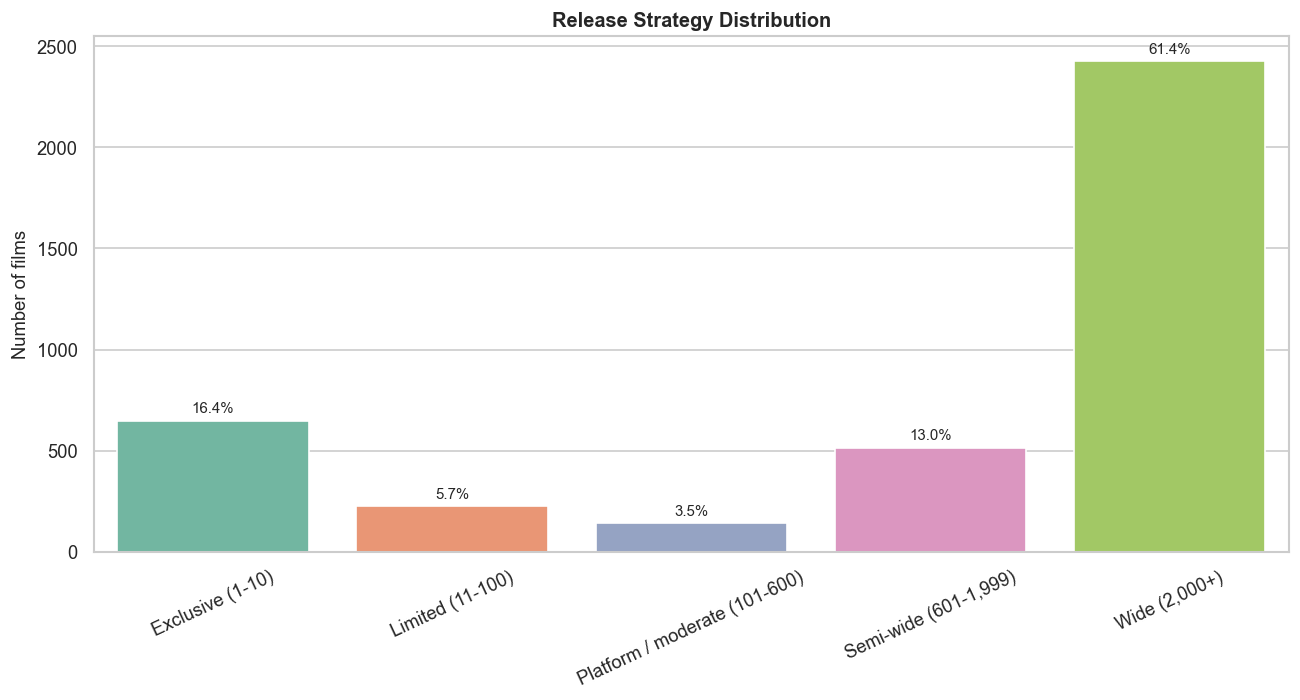

In [5]:
strategy_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        share_of_sample=("movie_name", lambda s: len(s) / len(eda) * 100),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        median_expansion_ratio=("theater_expansion_ratio", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
        median_legs=("legs", "median"),
        median_roi_worldwide=("roi_worldwide", "median"),
        platform_expansion_pct=("platform_expansion_flag", pct_mean),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

save_table(strategy_summary, "table_05_release_strategy_summary", "Film counts and median outcomes by release-strategy bucket.")
display(strategy_summary)

fig, ax = plt.subplots(figsize=(11, 6))
bar_data = strategy_summary.copy()
sns.barplot(data=bar_data, x="release_strategy", y="films", palette=strategy_palette, ax=ax, order=release_order)
ax.set_title("Release Strategy Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of films")
ax.tick_params(axis="x", rotation=25)
for p, share in zip(ax.patches, bar_data["share_of_sample"]):
    ax.annotate(f"{share:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
save_figure(fig, "fig_01_release_strategy_distribution", "Distribution of films by opening-theater release strategy.")
plt.show()


**Release-strategy commentary.** Wide openings dominate the sample, which is expected for a top-movie dataset. Scarce openings are therefore not the norm, but they are visible enough to analyze as a distinct rollout model. The key scarcity pattern for the thesis is not simply "few theaters"; it is the combination of few opening theaters, later expansion, strong reception, and enough demand to create long theatrical life.


## 4. Distribution of Opening Theaters

Opening theaters are the most direct measure of initial access. A low value means very few audiences could see the film immediately, while a wide opening makes the film broadly accessible from the beginning.


Saved figure: figures/fig_02_opening_theater_distribution.png


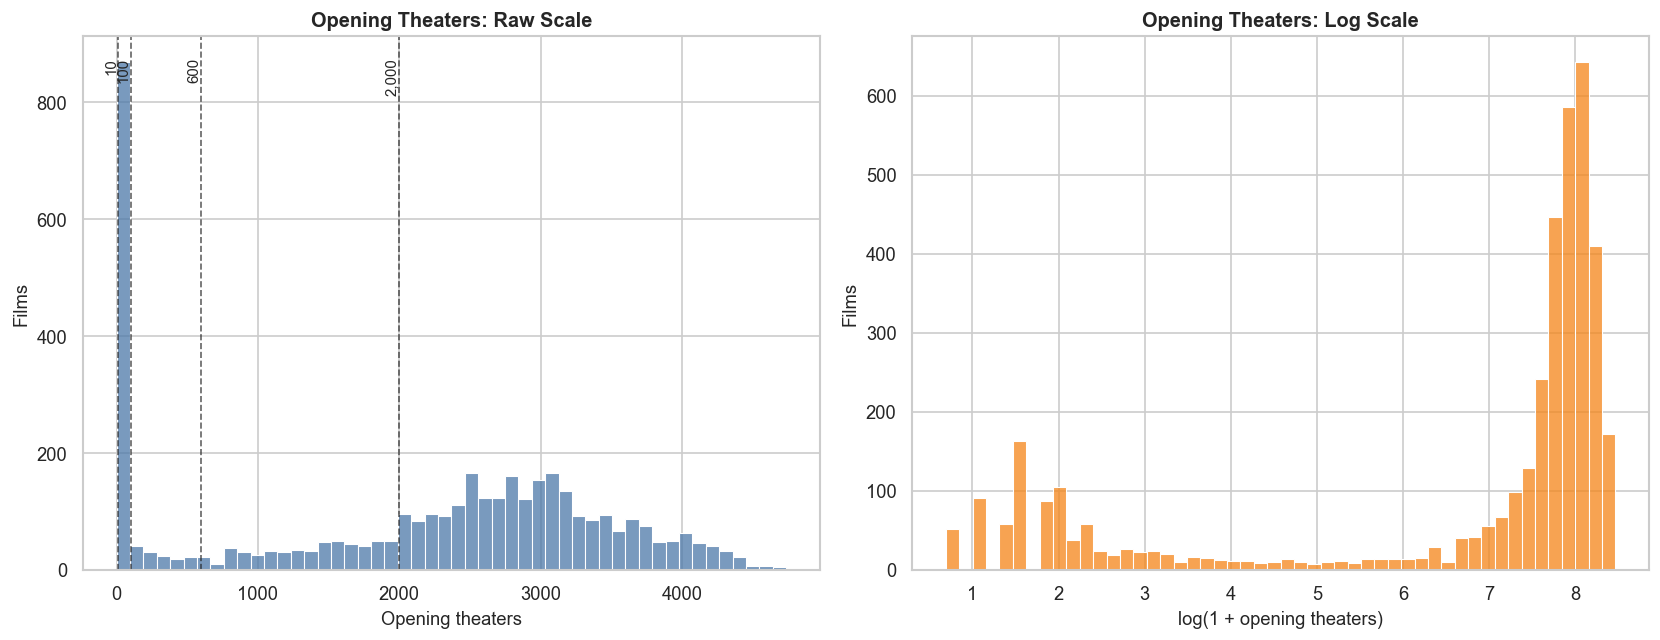

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(eda["opening_theaters"], bins=50, color="#4C78A8", ax=axes[0])
axes[0].set_title("Opening Theaters: Raw Scale")
axes[0].set_xlabel("Opening theaters")
axes[0].set_ylabel("Films")
for x, label in [(10, "10"), (100, "100"), (600, "600"), (2000, "2,000")]:
    axes[0].axvline(x, color="#222222", linestyle="--", linewidth=1, alpha=.7)
    axes[0].text(x, axes[0].get_ylim()[1] * .96, label, rotation=90, va="top", ha="right", fontsize=9)

sns.histplot(eda["log_opening_theaters_calc"], bins=50, color="#F58518", ax=axes[1])
axes[1].set_title("Opening Theaters: Log Scale")
axes[1].set_xlabel("log(1 + opening theaters)")
axes[1].set_ylabel("Films")

plt.tight_layout()
save_figure(fig, "fig_02_opening_theater_distribution", "Raw and log-scale distributions of opening-theater counts.")
plt.show()


**Opening-theater commentary.** The raw distribution shows a strong split between very small openings and broad commercial openings. The log view makes the scarce end visible, which matters because the symbolic-scarcity argument is most relevant among films that begin with deliberately restricted access.


## 5. Scarcity Versus IMDb Rating

IMDb rating is not a perfect measure of artistic value, but it is a usable audience-reception proxy. If scarcity sometimes functions as a prestige signal, scarce or platformed films should not simply look like weak performers; they should include films with strong ratings and later audience validation.


Saved table: figures/table_06_imdb_by_release_strategy.csv
Saved table: figures/table_06_imdb_by_release_strategy.html
Saved table: figures/table_07_imdb_by_opening_scarcity_decile.csv
Saved table: figures/table_07_imdb_by_opening_scarcity_decile.html


,release_strategy,films,rated_films,median_imdb_rating,mean_imdb_rating,median_imdb_votes,high_rating_7_plus_pct
0,Exclusive (1-10),648,600,7.10,7.03,"53,281.00",55.86
1,Limited (11-100),227,213,7.00,6.91,"42,352.00",48.90
2,Platform / moderate (101-600),140,138,6.70,6.56,"46,148.00",40.71
3,"Semi-wide (601-1,999)",515,505,6.50,6.45,"52,624.00",32.43
4,"Wide (2,000+)",2429,2405,6.30,6.28,"118,461.50",22.73


,scarcity_decile,films,median_opening_theaters,median_imdb_rating,mean_imdb_rating
0,D1 most scarce,387,4.00,7.10,7.03
1,D2,386,10.00,7.10,6.98
2,D3,386,716.00,6.70,6.61
3,D4,386,"1,770.50",6.40,6.32
4,D5,386,"2,304.50",6.20,6.15
5,D6,386,"2,603.50",6.20,6.13
6,D7,386,"2,860.00",6.30,6.26
7,D8,386,"3,117.00",6.30,6.21
8,D9,386,"3,469.00",6.30,6.28
9,D10 least scarce,386,"4,014.50",6.60,6.69


Saved figure: figures/fig_03_scarcity_vs_imdb_rating.png


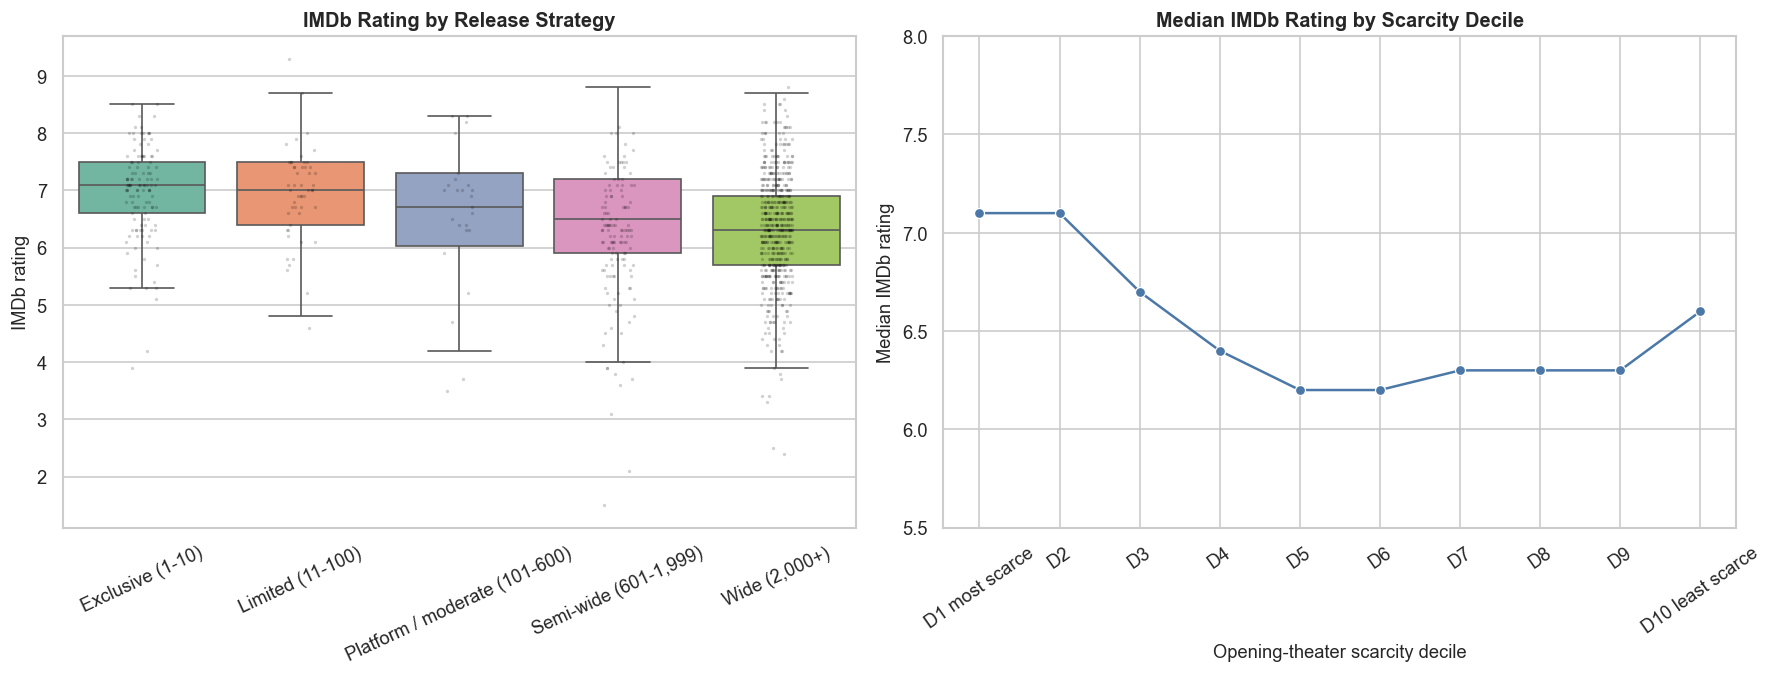

In [7]:
rating_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        rated_films=("imdb_rating_num", "count"),
        median_imdb_rating=("imdb_rating_num", "median"),
        mean_imdb_rating=("imdb_rating_num", "mean"),
        median_imdb_votes=("imdb_votes_num", "median"),
        high_rating_7_plus_pct=("imdb_rating_num", lambda s: (s >= 7).mean() * 100),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

scarcity_rating_deciles = eda.dropna(subset=["imdb_rating_num"]).copy()
scarcity_rating_deciles["scarcity_decile"] = pd.qcut(
    scarcity_rating_deciles["opening_theaters"].rank(method="first"),
    10,
    labels=["D1 most scarce", "D2", "D3", "D4", "D5", "D6", "D7", "D8", "D9", "D10 least scarce"],
)
decile_rating = (
    scarcity_rating_deciles.groupby("scarcity_decile", observed=False)
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
        mean_imdb_rating=("imdb_rating_num", "mean"),
    )
    .reset_index()
    .round(2)
)

save_table(rating_summary, "table_06_imdb_by_release_strategy", "IMDb rating and vote summary by release strategy.")
save_table(decile_rating, "table_07_imdb_by_opening_scarcity_decile", "IMDb rating summary by opening-theater scarcity decile.")
display(rating_summary)
display(decile_rating)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
plot_df = eda.dropna(subset=["imdb_rating_num", "release_strategy"])

sns.boxplot(data=plot_df, x="release_strategy", y="imdb_rating_num", order=release_order, palette=strategy_palette, showfliers=False, ax=axes[0])
sns.stripplot(data=plot_df.sample(min(len(plot_df), 900), random_state=42), x="release_strategy", y="imdb_rating_num", order=release_order, color="black", alpha=.18, size=2, ax=axes[0])
axes[0].set_title("IMDb Rating by Release Strategy")
axes[0].set_xlabel("")
axes[0].set_ylabel("IMDb rating")
axes[0].tick_params(axis="x", rotation=25)

sns.lineplot(data=decile_rating, x="scarcity_decile", y="median_imdb_rating", marker="o", color="#4C78A8", ax=axes[1])
axes[1].set_title("Median IMDb Rating by Scarcity Decile")
axes[1].set_xlabel("Opening-theater scarcity decile")
axes[1].set_ylabel("Median IMDb rating")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylim(5.5, max(8.0, decile_rating["median_imdb_rating"].max() + .2))

plt.tight_layout()
save_figure(fig, "fig_03_scarcity_vs_imdb_rating", "IMDb rating distributions by release strategy and scarcity decile.")
plt.show()


**IMDb commentary.** IMDb patterns can support, but not prove, the symbolic-value argument. A scarce opening associated with strong ratings is consistent with the idea that scarcity can accompany perceived quality. A weak or flat pattern would suggest scarcity is more likely a practical distribution constraint. Because IMDb ratings are post-release audience measures, they should be interpreted together with rollout and expansion rather than as direct evidence of prestige signaling.


## 6. Scarcity Versus Box Office Performance

Scarcity should not be expected to increase raw box office for every film. A limited opening mechanically restricts early revenue. The more relevant question is whether scarce openings can coexist with later commercial expansion, strong worldwide performance, or unusually efficient ROI.


Saved table: figures/table_08_box_office_by_release_strategy.csv
Saved table: figures/table_08_box_office_by_release_strategy.html


,release_strategy,films,median_budget,median_opening_weekend,median_domestic_box,median_worldwide_box,median_domestic_share,profitable_worldwide_pct
0,Exclusive (1-10),648,"9,000,000.00","86,833.50","4,539,374.00","12,932,538.00",45.55,65.12
1,Limited (11-100),227,"10,000,000.00","248,847.00","4,404,154.00","17,025,444.00",45.30,63.44
2,Platform / moderate (101-600),140,"12,000,000.00","1,372,680.50","5,103,392.00","14,242,159.00",48.15,56.43
3,"Semi-wide (601-1,999)",515,"17,000,000.00","5,582,079.00","19,005,109.00","28,649,556.00",69.70,70.10
4,"Wide (2,000+)",2429,"45,000,000.00","16,728,411.00","54,760,791.00","105,078,449.00",51.10,84.69


Saved figure: figures/fig_04_scarcity_vs_box_office.png


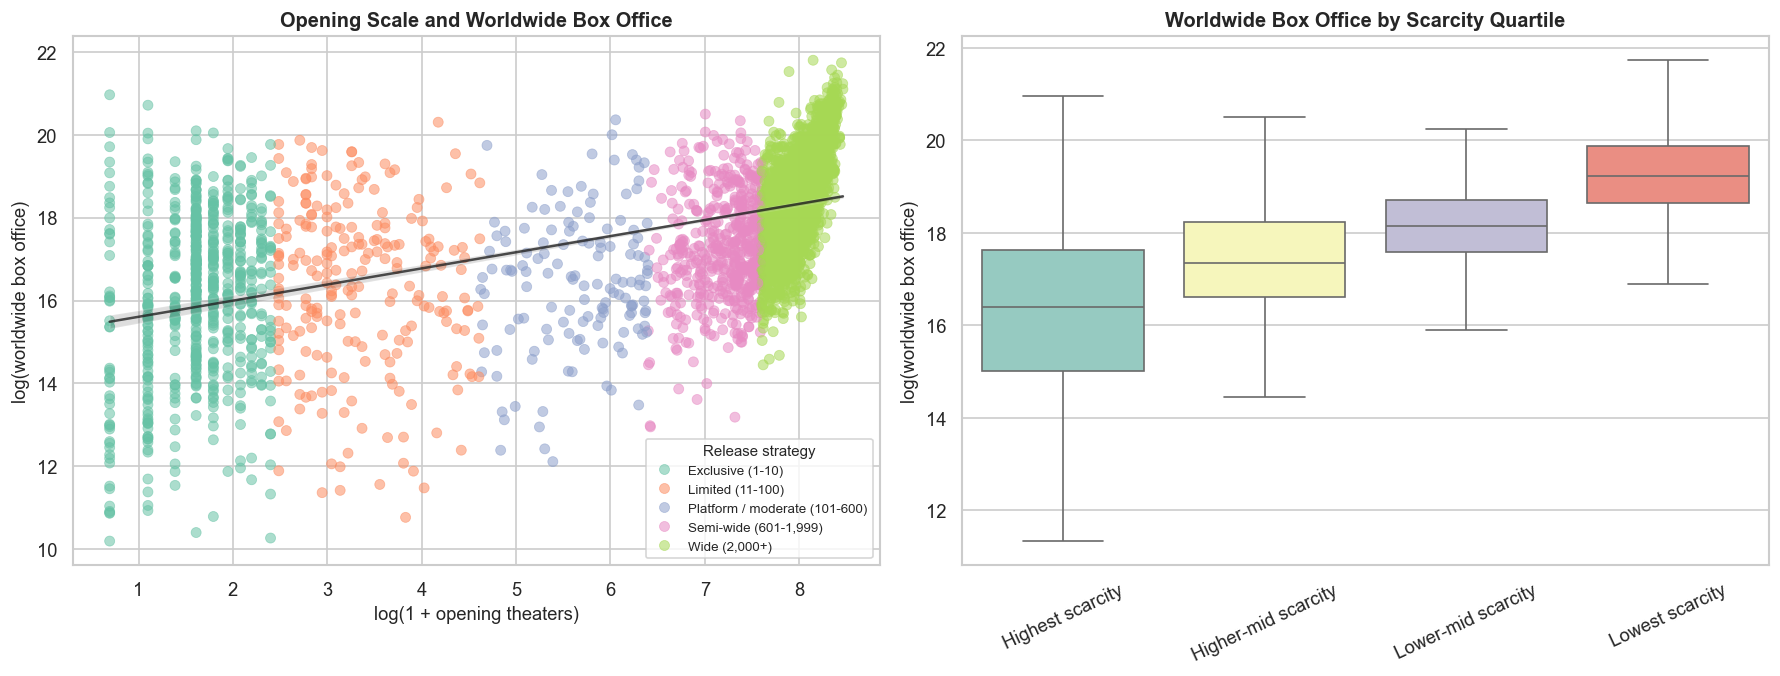

In [8]:
performance_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        median_budget=("production_budget_usd", "median"),
        median_opening_weekend=("opening_weekend_usd", "median"),
        median_domestic_box=("domestic_box_office_usd", "median"),
        median_worldwide_box=("worldwide_box_office_usd", "median"),
        median_domestic_share=("domestic_share_percentage", "median"),
        profitable_worldwide_pct=("profit_worldwide", lambda s: (s > 0).mean() * 100),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

save_table(performance_summary, "table_08_box_office_by_release_strategy", "Budget and box office medians by release strategy.")
display(performance_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

sns.scatterplot(data=eda, x="log_opening_theaters_calc", y="log_worldwide_box_office", hue="release_strategy", hue_order=release_order, palette=strategy_palette, alpha=.55, s=36, edgecolor=None, ax=axes[0])
sns.regplot(data=eda, x="log_opening_theaters_calc", y="log_worldwide_box_office", scatter=False, color="#222222", line_kws={"linewidth": 1.5, "alpha": .8}, ax=axes[0])
axes[0].set_title("Opening Scale and Worldwide Box Office")
axes[0].set_xlabel("log(1 + opening theaters)")
axes[0].set_ylabel("log(worldwide box office)")
axes[0].legend(title="Release strategy", fontsize=8, title_fontsize=9, loc="lower right")

sns.boxplot(data=eda, x="scarcity_quartile", y="log_worldwide_box_office", palette="Set3", showfliers=False, ax=axes[1])
axes[1].set_title("Worldwide Box Office by Scarcity Quartile")
axes[1].set_xlabel("")
axes[1].set_ylabel("log(worldwide box office)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
save_figure(fig, "fig_04_scarcity_vs_box_office", "Relationship between opening scarcity and worldwide box office performance.")
plt.show()


**Box office commentary.** Wide releases have a structural advantage in raw revenue because they are immediately available to more people. For the thesis, the interesting scarce films are therefore not those that beat blockbusters on total gross, but those that convert limited access into expansion, long legs, strong ratings, or high ROI.


## 7. Scarcity Versus Legs

`legs` measures final domestic gross relative to opening weekend. It is a useful rollout variable because platform releases and word-of-mouth films can have long post-opening lives. However, legs can be mechanically high when the opening weekend starts from a very small base, so it should be interpreted with opening-theater scale and expansion.


Saved table: figures/table_09_legs_by_release_strategy.csv
Saved table: figures/table_09_legs_by_release_strategy.html


,release_strategy,films,median_legs,mean_legs,high_legs_pct,median_opening_weekend,median_avg_weeks_per_theater
0,Exclusive (1-10),648,6.66,8.34,79.32,"86,833.50",5.60
1,Limited (11-100),227,4.71,6.39,60.35,"248,847.00",4.40
2,Platform / moderate (101-600),140,3.51,5.19,40.71,"1,372,680.50",3.60
3,"Semi-wide (601-1,999)",515,3.27,4.28,35.92,"5,582,079.00",4.30
4,"Wide (2,000+)",2429,2.95,3.24,18.44,"16,728,411.00",4.80


Saved figure: figures/fig_05_scarcity_vs_legs.png


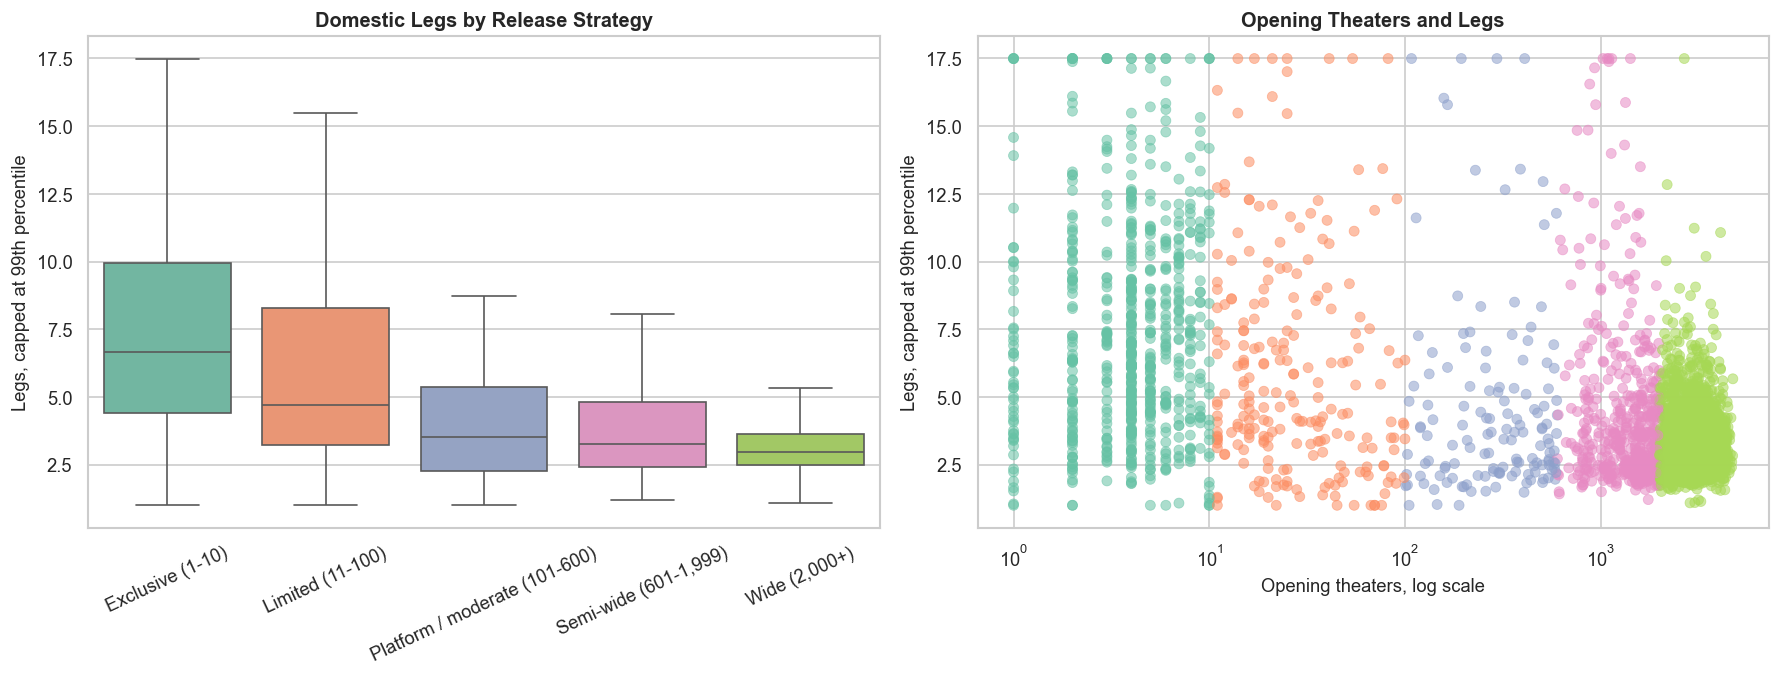

In [9]:
legs_threshold = 4
legs_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        median_legs=("legs", "median"),
        mean_legs=("legs", "mean"),
        high_legs_pct=("legs", lambda s: (s >= legs_threshold).mean() * 100),
        median_opening_weekend=("opening_weekend_usd", "median"),
        median_avg_weeks_per_theater=("avg_weeks_per_theater", "median"),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

save_table(legs_summary, "table_09_legs_by_release_strategy", "Legs and theatrical staying-power metrics by release strategy.")
display(legs_summary)

eda["legs_capped_99"] = eda["legs"].clip(upper=eda["legs"].quantile(.99))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

sns.boxplot(data=eda, x="release_strategy", y="legs_capped_99", order=release_order, palette=strategy_palette, showfliers=False, ax=axes[0])
axes[0].set_title("Domestic Legs by Release Strategy")
axes[0].set_xlabel("")
axes[0].set_ylabel("Legs, capped at 99th percentile")
axes[0].tick_params(axis="x", rotation=25)

sns.scatterplot(data=eda, x="opening_theaters", y="legs_capped_99", hue="release_strategy", hue_order=release_order, palette=strategy_palette, alpha=.55, s=36, edgecolor=None, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Opening Theaters and Legs")
axes[1].set_xlabel("Opening theaters, log scale")
axes[1].set_ylabel("Legs, capped at 99th percentile")
axes[1].legend_.remove()

plt.tight_layout()
save_figure(fig, "fig_05_scarcity_vs_legs", "Domestic legs by release strategy and opening-theater scale.")
plt.show()


**Legs commentary.** High legs among scarce openings can indicate gradual discovery and word of mouth, but it can also reflect a tiny opening denominator. The thesis should therefore treat legs as supportive evidence only when paired with later theater expansion and strong audience/artistic reception.


## 8. Theater Expansion EDA

Expansion is central to the Parasite-style scarcity story. A film that opens in a few theaters and later reaches a large footprint has moved from restricted access to broader cultural visibility. This pattern is closer to symbolic scarcity than a film that simply remains unavailable.


Saved table: figures/table_10_theater_expansion_by_strategy.csv
Saved table: figures/table_10_theater_expansion_by_strategy.html
Saved table: figures/table_11_top_platform_expansions.csv
Saved table: figures/table_11_top_platform_expansions.html


,release_strategy,films,median_opening_theaters,median_max_theaters,median_expansion_ratio,median_opening_to_max_ratio,platform_expansion_pct,major_expansion_pct
0,Exclusive (1-10),648,4.00,267.50,61.56,0.02,24.23,24.23
1,Limited (11-100),227,24.00,259.00,10.11,0.10,28.63,28.63
2,Platform / moderate (101-600),140,304.50,457.50,1.02,0.98,0.00,2.86
3,"Semi-wide (601-1,999)",515,"1,495.00","1,585.00",1.01,0.99,0.00,0.00
4,"Wide (2,000+)",2429,"2,981.00","3,014.00",1.00,1.00,0.00,0.00


,movie_name,release_year,genre,opening_theaters,max_theaters,theater_expansion_ratio,opening_to_max_ratio,imdb_rating_num,legs,worldwide_box_office_usd,roi_worldwide
209,Frozen,2013,Musical,1.00,"3,742.00","3,742.00",0.00,7.40,5.95,"1,271,023,300.00",8.47
520,Toy Story 2,1999,Adventure,1.00,"3,257.00","3,257.00",0.00,7.90,4.28,"511,358,276.00",5.68
799,Hercules,1997,Adventure,1.00,"2,930.00","2,930.00",0.00,7.30,4.62,"250,700,000.00",3.58
1308,A Bug’s Life,1998,Adventure,1.00,"2,773.00","2,773.00",0.00,7.20,4.90,"363,095,319.00",8.07
1130,Anastasia,1997,Musical,1.00,"2,514.00","2,514.00",0.00,7.20,4.14,"139,801,096.00",2.64
412,The Princess and the Frog,2009,Adventure,2.00,"3,475.00","1,737.50",0.00,7.20,4.31,"270,997,378.00",2.58
1795,Mr. Holland’s Opus,1995,Drama,1.00,"1,659.00","1,659.00",0.00,7.30,8.92,"106,282,604.00",3.43
1428,Lone Survivor,2013,Action,2.00,"3,285.00","1,642.50",0.00,7.30,3.31,"149,804,632.00",3.75
542,Atlantis: The Lost Empire,2001,Adventure,2.00,"3,071.00","1,535.50",0.00,6.90,4.13,"186,049,020.00",2.07
1302,Brother Bear,2003,Adventure,2.00,"3,030.00","1,515.00",0.00,6.90,4.40,"250,397,798.00",5.44


Saved figure: figures/fig_06_theater_expansion.png


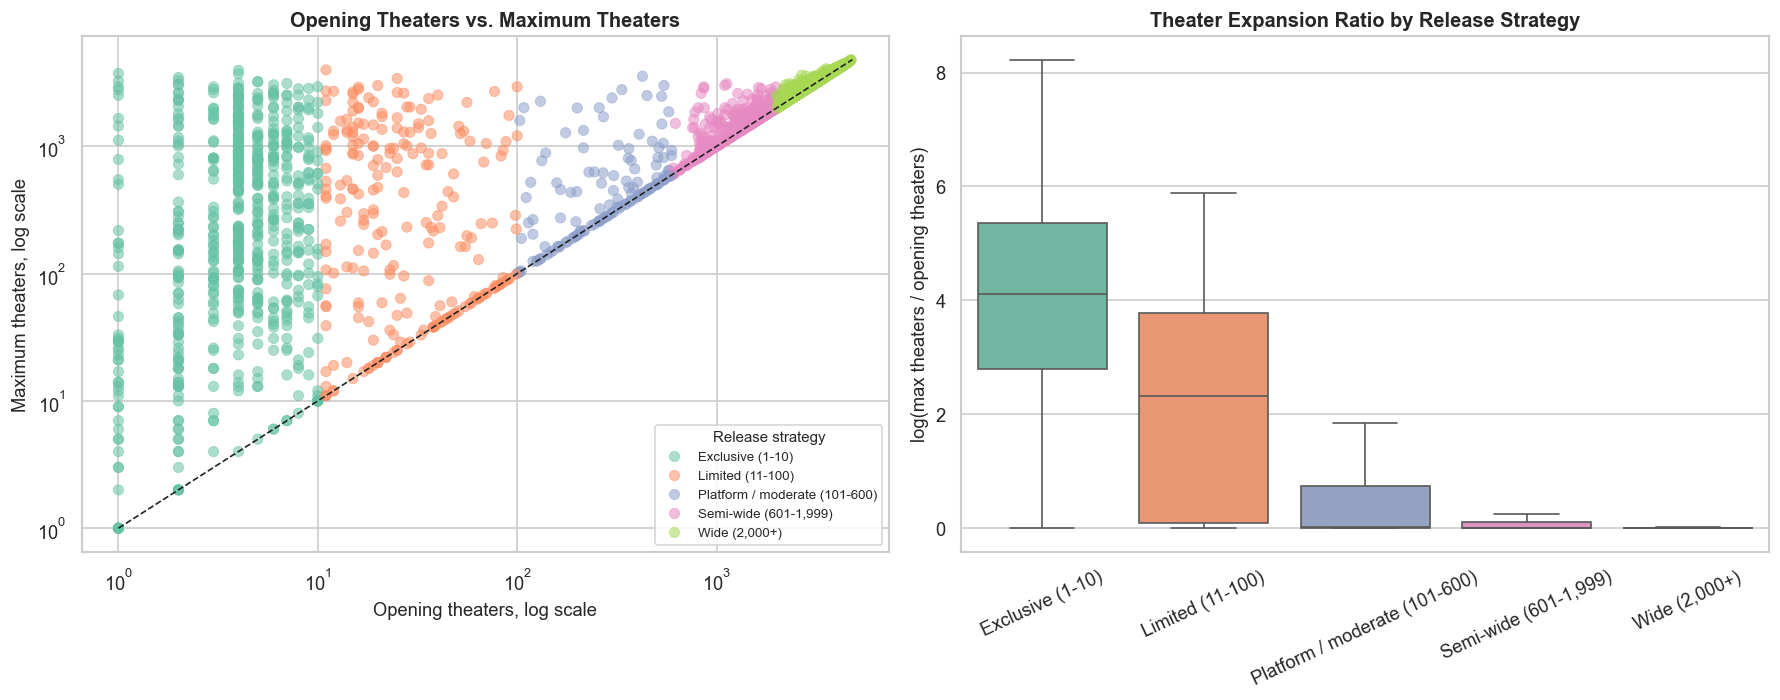

In [10]:
expansion_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        median_expansion_ratio=("theater_expansion_ratio", "median"),
        median_opening_to_max_ratio=("opening_to_max_ratio", "median"),
        platform_expansion_pct=("platform_expansion_flag", pct_mean),
        major_expansion_pct=("major_expansion_flag", pct_mean),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

top_platform_expansions = (
    eda.loc[eda["max_theaters"] >= 1000, [
        "movie_name", "release_year", "genre", "opening_theaters", "max_theaters",
        "theater_expansion_ratio", "opening_to_max_ratio", "imdb_rating_num",
        "legs", "worldwide_box_office_usd", "roi_worldwide"
    ]]
    .sort_values("theater_expansion_ratio", ascending=False)
    .head(25)
    .assign(
        worldwide_box_office_usd=lambda x: x["worldwide_box_office_usd"].round(0),
        theater_expansion_ratio=lambda x: x["theater_expansion_ratio"].round(2),
        opening_to_max_ratio=lambda x: x["opening_to_max_ratio"].round(4),
        roi_worldwide=lambda x: x["roi_worldwide"].round(2),
    )
)

save_table(expansion_summary, "table_10_theater_expansion_by_strategy", "Theater expansion metrics by release strategy.")
save_table(top_platform_expansions, "table_11_top_platform_expansions", "Films with the largest theater expansion ratios among titles reaching at least 1,000 theaters.")
display(expansion_summary)
display(top_platform_expansions)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=eda, x="opening_theaters", y="max_theaters", hue="release_strategy", hue_order=release_order, palette=strategy_palette, alpha=.55, s=38, edgecolor=None, ax=axes[0])
axes[0].plot([1, eda["max_theaters"].max()], [1, eda["max_theaters"].max()], color="#222222", linestyle="--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Opening Theaters vs. Maximum Theaters")
axes[0].set_xlabel("Opening theaters, log scale")
axes[0].set_ylabel("Maximum theaters, log scale")
axes[0].legend(title="Release strategy", fontsize=8, title_fontsize=9, loc="lower right")

sns.boxplot(data=eda, x="release_strategy", y="log_expansion_ratio", order=release_order, palette=strategy_palette, showfliers=False, ax=axes[1])
axes[1].set_title("Theater Expansion Ratio by Release Strategy")
axes[1].set_xlabel("")
axes[1].set_ylabel("log(max theaters / opening theaters)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
save_figure(fig, "fig_06_theater_expansion", "Opening-to-maximum theater expansion patterns.")
plt.show()


**Expansion commentary.** The clearest quantitative version of symbolic scarcity is not just low initial supply; it is low initial supply followed by expansion. That sequence suggests that restricted access helped stage the film as a discovery object before broader availability.


## 9. Scarcity and ROI

ROI helps distinguish revenue scale from efficiency. A mainstream event film may dominate gross revenue, while a scarce platform film may be more efficient relative to its budget. ROI is highly skewed, so plots use log or capped values.


Saved table: figures/table_12_roi_by_release_strategy.csv
Saved table: figures/table_12_roi_by_release_strategy.html


,release_strategy,films,median_budget,median_worldwide_box,median_roi_worldwide,mean_roi_worldwide,profitable_worldwide_pct,high_roi_5x_pct
0,Exclusive (1-10),648,"9,000,000.00","12,932,538.00",1.85,5.13,65.12,23.92
1,Limited (11-100),227,"10,000,000.00","17,025,444.00",1.89,9.12,63.44,24.23
2,Platform / moderate (101-600),140,"12,000,000.00","14,242,159.00",1.41,4.33,56.43,20.00
3,"Semi-wide (601-1,999)",515,"17,000,000.00","28,649,556.00",1.95,4.69,70.10,23.50
4,"Wide (2,000+)",2429,"45,000,000.00","105,078,449.00",2.58,3.93,84.69,19.18


Saved figure: figures/fig_07_scarcity_and_roi.png


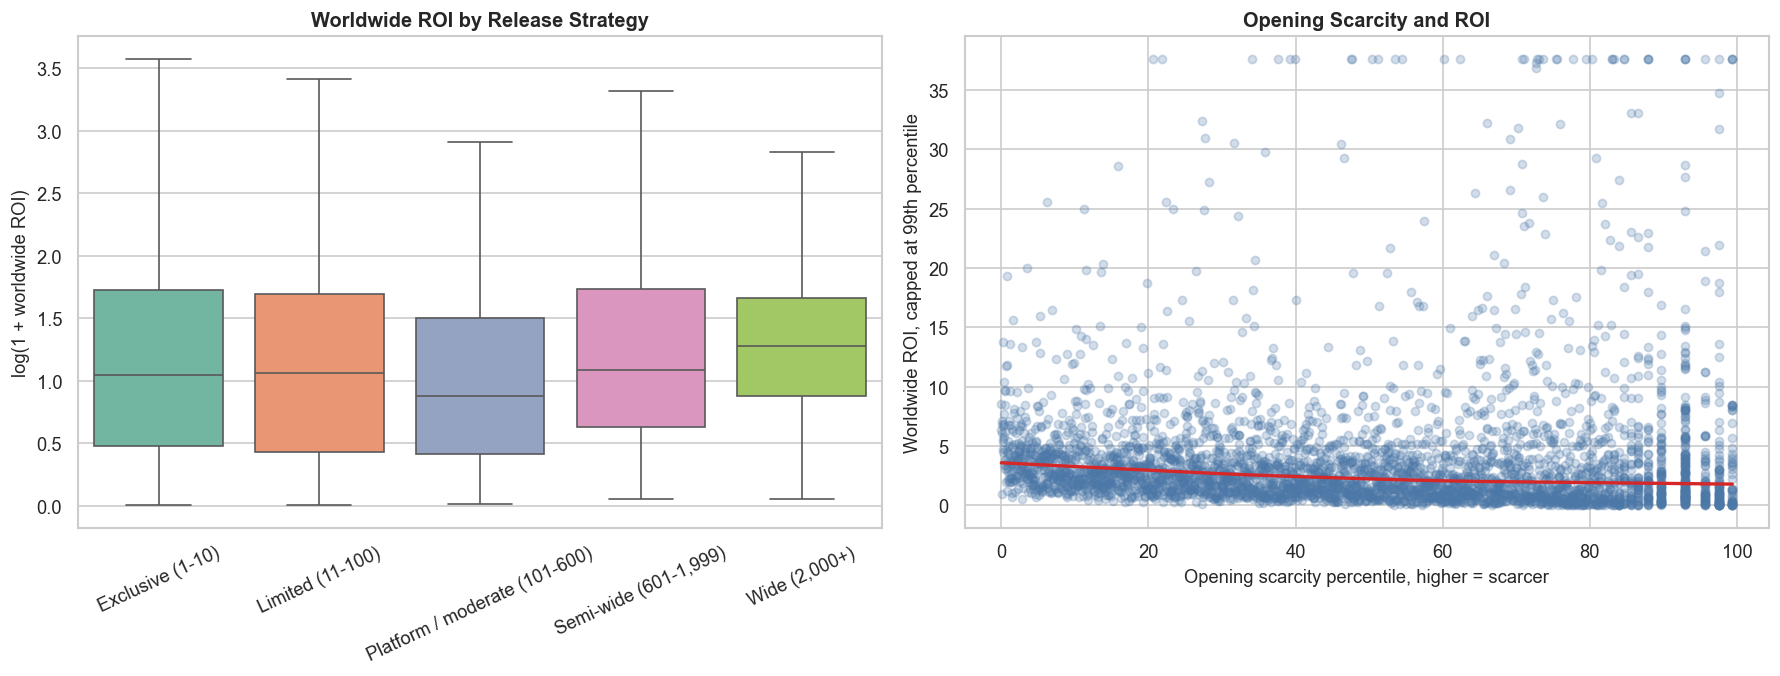

In [11]:
roi_summary = (
    eda.groupby("release_strategy", observed=False)
    .agg(
        films=("movie_name", "count"),
        median_budget=("production_budget_usd", "median"),
        median_worldwide_box=("worldwide_box_office_usd", "median"),
        median_roi_worldwide=("roi_worldwide", "median"),
        mean_roi_worldwide=("roi_worldwide", "mean"),
        profitable_worldwide_pct=("profit_worldwide", lambda s: (s > 0).mean() * 100),
        high_roi_5x_pct=("roi_worldwide", lambda s: (s >= 5).mean() * 100),
    )
    .reindex(release_order)
    .reset_index()
    .round(2)
)

save_table(roi_summary, "table_12_roi_by_release_strategy", "Worldwide ROI and profitability by release strategy.")
display(roi_summary)

eda["roi_worldwide_capped_99"] = eda["roi_worldwide"].clip(upper=eda["roi_worldwide"].quantile(.99))
eda["log_roi_worldwide"] = np.log1p(eda["roi_worldwide"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

sns.boxplot(data=eda, x="release_strategy", y="log_roi_worldwide", order=release_order, palette=strategy_palette, showfliers=False, ax=axes[0])
axes[0].set_title("Worldwide ROI by Release Strategy")
axes[0].set_xlabel("")
axes[0].set_ylabel("log(1 + worldwide ROI)")
axes[0].tick_params(axis="x", rotation=25)

sns.regplot(data=eda, x="opening_scarcity_pct", y="roi_worldwide_capped_99", lowess=True, scatter_kws={"alpha": .25, "s": 24, "color": "#4C78A8"}, line_kws={"color": "#D62728", "linewidth": 2}, ax=axes[1])
axes[1].set_title("Opening Scarcity and ROI")
axes[1].set_xlabel("Opening scarcity percentile, higher = scarcer")
axes[1].set_ylabel("Worldwide ROI, capped at 99th percentile")

plt.tight_layout()
save_figure(fig, "fig_07_scarcity_and_roi", "Worldwide ROI by release strategy and opening-scarcity score.")
plt.show()


**ROI commentary.** ROI is the place where scarcity can look economically rational even when total revenue is smaller. If limited/platform films show competitive ROI, that supports the managerial argument that controlled access can build value without requiring blockbuster-scale availability.


## 10. Arthouse/Prestige Proxies Versus Mainstream/Event Proxies

The dataset has no festival or awards variable, so this section uses cautious proxies. The labels below should not be read as final genre identities. They are analytical groupings built from release scale, franchise status, budget, genre, source, and creative type.


Saved table: figures/table_13_positioning_proxy_summary.csv
Saved table: figures/table_13_positioning_proxy_summary.html
Saved table: figures/table_14_positioning_proxy_strategy_mix.csv
Saved table: figures/table_14_positioning_proxy_strategy_mix.html


,positioning_proxy,films,median_opening_theaters,median_max_theaters,median_budget,median_worldwide_box,median_imdb_rating,median_legs,median_roi_worldwide,platform_expansion_pct,wide_opening_pct
0,Arthouse/prestige proxy,924,6.00,284.50,"9,550,000.00","11,564,315.50",7.00,5.92,1.58,20.13,0.00
1,Mainstream/event proxy,2724,"2,861.00","2,921.50","40,000,000.00","101,266,561.50",6.40,3.01,2.62,1.32,89.17
2,Other / mixed proxy,311,"1,432.00","1,525.00","16,000,000.00","20,052,958.00",6.50,2.85,1.53,0.00,0.00


release_strategy,positioning_proxy,Exclusive (1-10),Limited (11-100),Platform / moderate (101-600),"Semi-wide (601-1,999)","Wide (2,000+)"
0,Arthouse/prestige proxy,65.04,22.19,12.77,0.00,0.00
1,Mainstream/event proxy,1.65,0.81,0.81,7.56,89.17
2,Other / mixed proxy,0.64,0.00,0.00,99.36,0.00


Saved figure: figures/fig_08_positioning_proxy_comparison.png


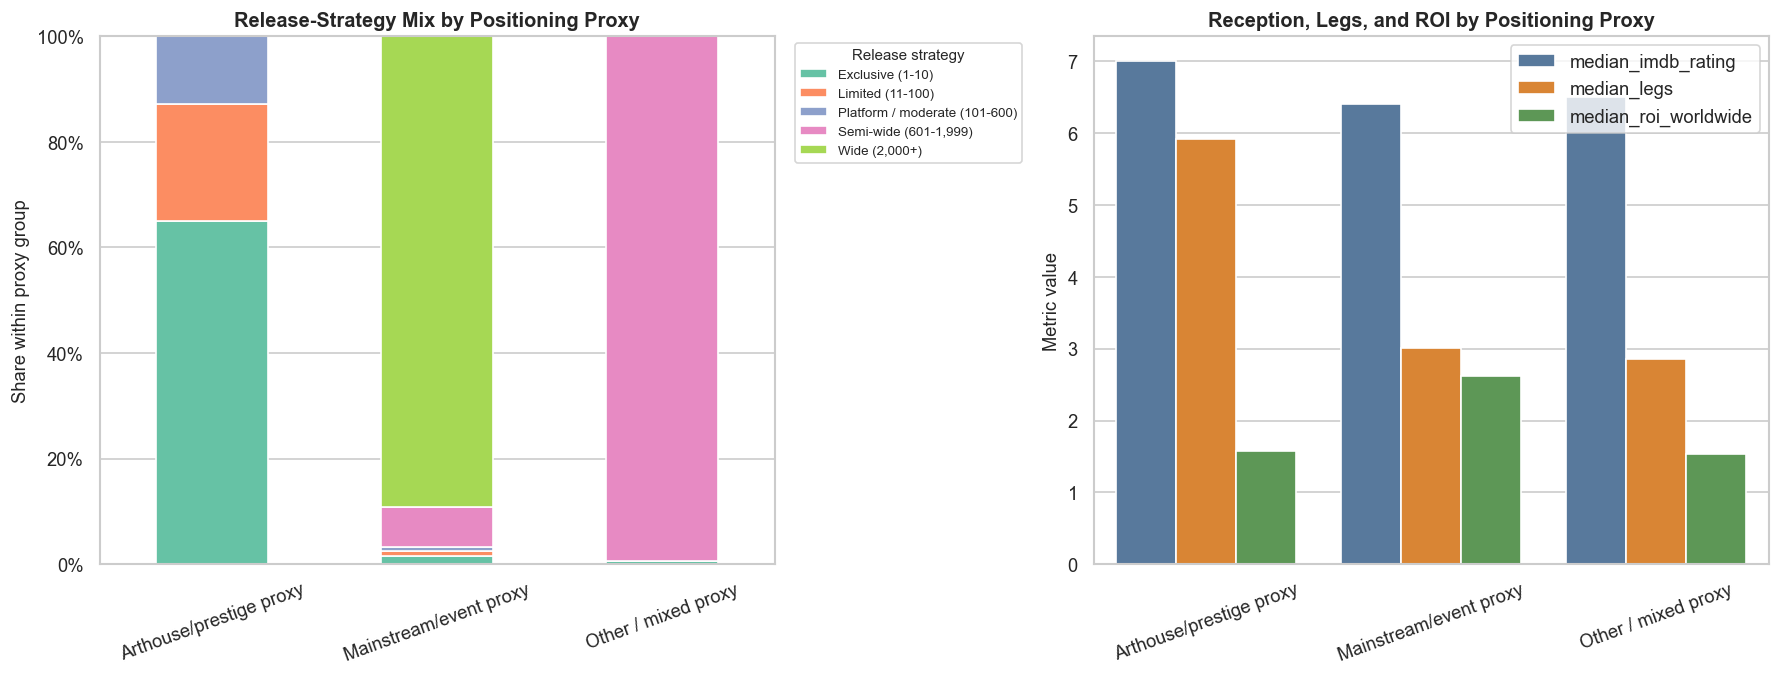

In [12]:
position_order = ["Arthouse/prestige proxy", "Mainstream/event proxy", "Other / mixed proxy"]

positioning_summary = (
    eda.groupby("positioning_proxy")
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        median_budget=("production_budget_usd", "median"),
        median_worldwide_box=("worldwide_box_office_usd", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
        median_legs=("legs", "median"),
        median_roi_worldwide=("roi_worldwide", "median"),
        platform_expansion_pct=("platform_expansion_flag", pct_mean),
        wide_opening_pct=("wide_opening_2000", pct_mean),
    )
    .reindex(position_order)
    .reset_index()
    .round(2)
)

strategy_mix = (
    pd.crosstab(eda["positioning_proxy"], eda["release_strategy"], normalize="index")
    .reindex(position_order)
    .reindex(columns=release_order)
    .mul(100)
    .round(2)
    .reset_index()
)

save_table(positioning_summary, "table_13_positioning_proxy_summary", "Summary metrics for arthouse/prestige, mainstream/event, and mixed proxy groups.")
save_table(strategy_mix, "table_14_positioning_proxy_strategy_mix", "Release-strategy mix within each positioning proxy group, row percentages.")
display(positioning_summary)
display(strategy_mix)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

mix_plot = strategy_mix.set_index("positioning_proxy")[release_order]
mix_plot.plot(kind="bar", stacked=True, color=[strategy_palette[x] for x in release_order], ax=axes[0])
axes[0].set_title("Release-Strategy Mix by Positioning Proxy")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share within proxy group")
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Release strategy", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)

metric_plot = positioning_summary.melt(id_vars="positioning_proxy", value_vars=["median_imdb_rating", "median_legs", "median_roi_worldwide"], var_name="metric", value_name="value")
sns.barplot(data=metric_plot, x="positioning_proxy", y="value", hue="metric", palette=["#4C78A8", "#F58518", "#54A24B"], ax=axes[1])
axes[1].set_title("Reception, Legs, and ROI by Positioning Proxy")
axes[1].set_xlabel("")
axes[1].set_ylabel("Metric value")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="")

plt.tight_layout()
save_figure(fig, "fig_08_positioning_proxy_comparison", "Comparison of release strategy and outcome metrics across positioning proxy groups.")
plt.show()


**Positioning commentary.** This comparison is directly relevant to the Parasite/Oppenheimer contrast. The dataset can distinguish a platform/prestige release logic from a mainstream/event release logic, but it cannot observe whether audiences experienced those strategies as status, distinction, authenticity, or inconvenience. That interpretive layer requires case-study evidence.


## 11. Genre-Level Scarcity

Genre is a useful way to see where scarcity is concentrated. Prestige-coded genres may be more compatible with limited openings, while action/adventure genres are usually built around broad initial access.


Saved table: figures/table_15_genre_level_scarcity.csv
Saved table: figures/table_15_genre_level_scarcity.html


,genre,films,median_opening_theaters,median_max_theaters,limited_opening_pct,wide_opening_pct,median_expansion_ratio,median_imdb_rating,median_legs,median_roi_worldwide
0,Drama,963,229.00,"1,318.00",48.08,30.01,1.30,7.00,4.37,1.89
1,Comedy,660,"2,506.50","2,551.00",17.58,63.79,1.01,6.20,3.34,2.30
2,Action,595,"2,951.00","2,996.00",4.71,83.87,1.00,6.40,2.79,2.40
3,Adventure,517,"3,369.00","3,425.00",4.45,88.20,1.00,6.50,3.46,2.69
4,Thriller/Suspense,432,"2,402.50","2,456.50",19.44,65.28,1.00,6.50,3.04,1.80
5,Horror,353,"2,620.00","2,657.00",9.92,72.52,1.00,5.90,2.50,3.60
6,Romantic Comedy,204,"2,423.50","2,473.00",12.25,66.67,1.00,6.10,3.20,2.64
7,Black Comedy,83,"1,468.00","1,614.00",38.55,34.94,1.01,6.80,3.59,2.02
8,Musical,60,"2,207.50","2,808.50",41.67,51.67,1.03,6.90,4.18,2.65
9,Documentary,42,5.00,205.00,71.43,2.38,9.12,7.40,5.39,2.86


Saved figure: figures/fig_09_genre_level_scarcity.png


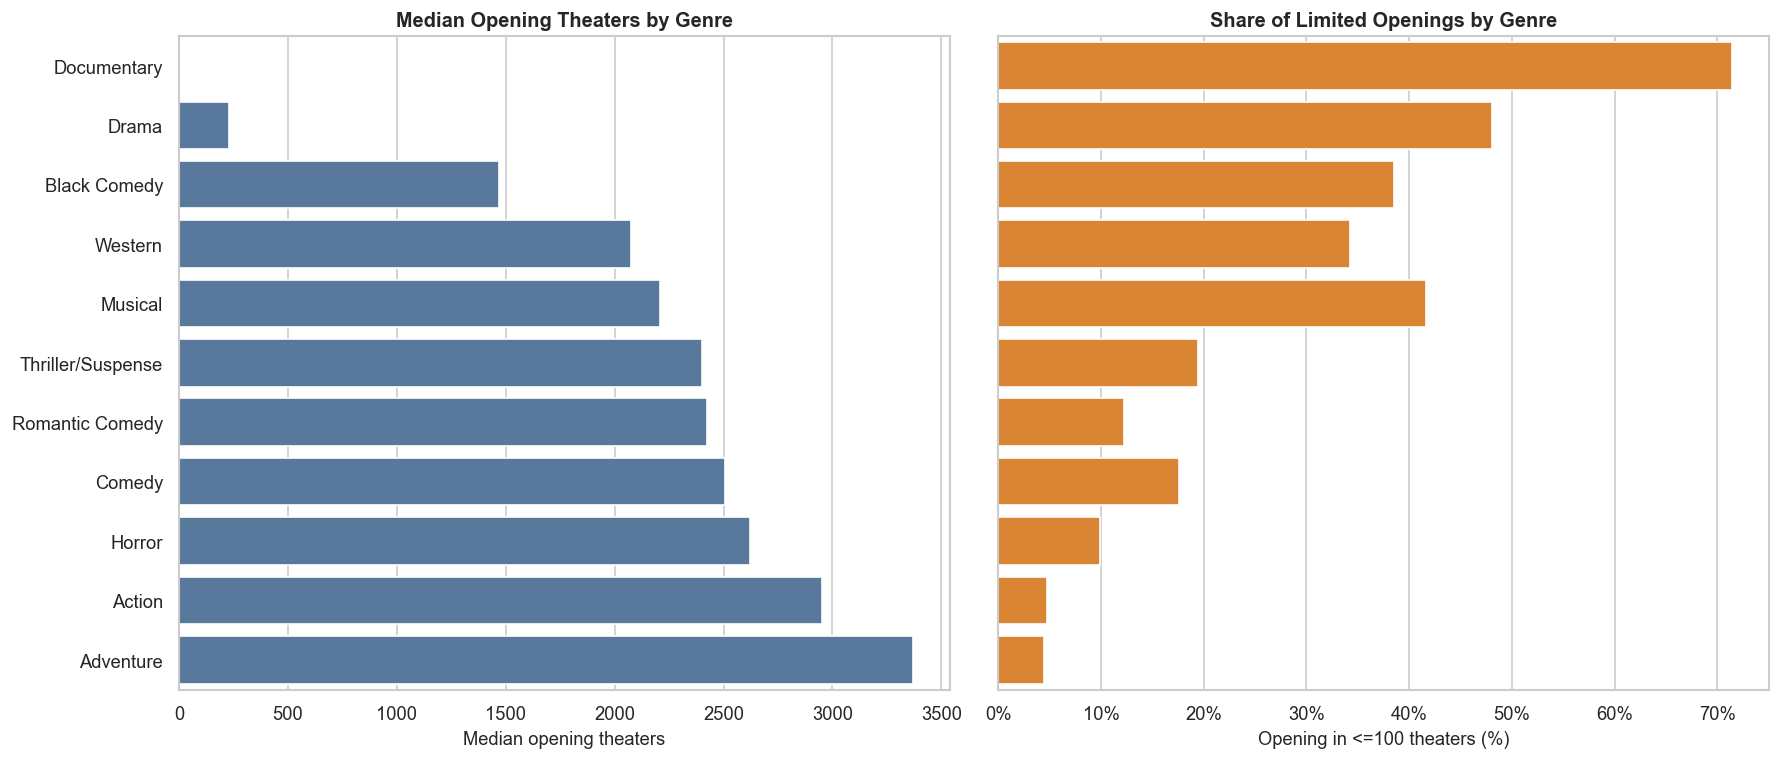

In [13]:
genre_summary = (
    eda.groupby("genre")
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        limited_opening_pct=("limited_opening_100", pct_mean),
        wide_opening_pct=("wide_opening_2000", pct_mean),
        median_expansion_ratio=("theater_expansion_ratio", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
        median_legs=("legs", "median"),
        median_roi_worldwide=("roi_worldwide", "median"),
    )
    .sort_values(["films", "median_opening_theaters"], ascending=[False, True])
    .reset_index()
    .round(2)
)

genre_plot = genre_summary.query("films >= 20").sort_values("median_opening_theaters")

save_table(genre_summary, "table_15_genre_level_scarcity", "Genre-level theater scarcity, expansion, rating, legs, and ROI metrics.")
display(genre_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
sns.barplot(data=genre_plot, y="genre", x="median_opening_theaters", color="#4C78A8", ax=axes[0])
axes[0].set_title("Median Opening Theaters by Genre")
axes[0].set_xlabel("Median opening theaters")
axes[0].set_ylabel("")
sns.barplot(data=genre_plot, y="genre", x="limited_opening_pct", color="#F58518", ax=axes[1])
axes[1].set_title("Share of Limited Openings by Genre")
axes[1].set_xlabel("Opening in <=100 theaters (%)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
save_figure(fig, "fig_09_genre_level_scarcity", "Genre-level differences in opening-theater scale and limited opening share.")
plt.show()


**Genre commentary.** Genre patterns help separate scarcity as positioning from scarcity as constraint. If drama, documentary, or black comedy show smaller openings and stronger expansion than action/adventure films, that supports the idea that scarcity is more compatible with prestige-coded categories than with broad-audience event categories.


## 12. Time Trend: Has Scarcity Changed Over Time?

The sample covers films released from the 1970s through 2025. Because the dataset is top-movie-oriented and 2025 may be incomplete, this is not a definitive industry trend. It is still useful for seeing whether the dataset's release strategies have shifted over time.


Saved table: figures/table_16_yearly_release_strategy_trend.csv
Saved table: figures/table_16_yearly_release_strategy_trend.html
Saved table: figures/table_17_decade_release_strategy_summary.csv
Saved table: figures/table_17_decade_release_strategy_summary.html


,decade,films,median_opening_theaters,median_max_theaters,limited_opening_pct,wide_opening_pct,median_expansion_ratio,median_imdb_rating
0,1970s,16,367.00,618.00,31.25,0.00,1.39,7.30
1,1980s,113,"1,091.00","1,384.00",13.27,6.19,1.07,7.20
2,1990s,416,"2,065.50","2,188.00",20.43,52.64,1.03,6.80
3,2000s,1538,"2,362.00","2,464.50",24.32,59.36,1.01,6.50
4,2010s,1593,"2,719.00","2,791.00",23.54,66.04,1.00,6.45
5,2020s,283,"3,375.00","3,408.00",7.42,84.10,1.00,6.40


Saved figure: figures/fig_10_time_trend_scarcity.png


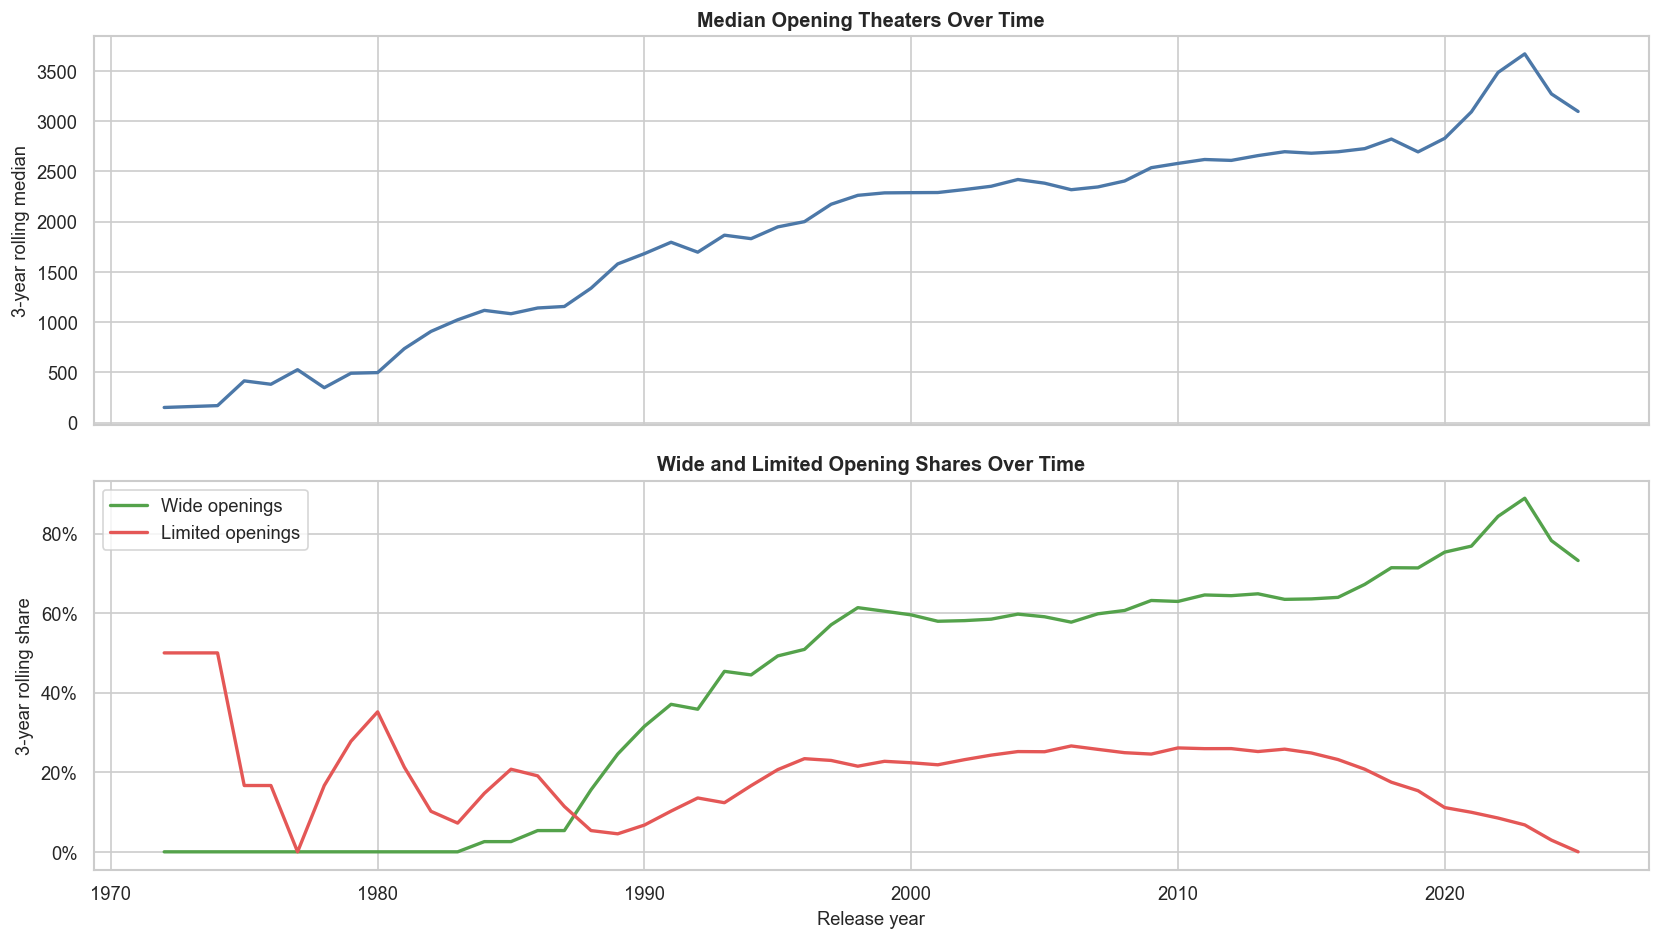

In [14]:
eda["decade"] = (eda["release_year"] // 10 * 10).astype(str) + "s"

yearly_trend = (
    eda.groupby("release_year")
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        limited_opening_pct=("limited_opening_100", pct_mean),
        wide_opening_pct=("wide_opening_2000", pct_mean),
        median_expansion_ratio=("theater_expansion_ratio", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
    )
    .reset_index()
    .round(2)
)

decade_summary = (
    eda.groupby("decade")
    .agg(
        films=("movie_name", "count"),
        median_opening_theaters=("opening_theaters", "median"),
        median_max_theaters=("max_theaters", "median"),
        limited_opening_pct=("limited_opening_100", pct_mean),
        wide_opening_pct=("wide_opening_2000", pct_mean),
        median_expansion_ratio=("theater_expansion_ratio", "median"),
        median_imdb_rating=("imdb_rating_num", "median"),
    )
    .reset_index()
    .round(2)
)

save_table(yearly_trend, "table_16_yearly_release_strategy_trend", "Year-level trends in opening scale and release-strategy shares.")
save_table(decade_summary, "table_17_decade_release_strategy_summary", "Decade-level trends in opening scale and release-strategy shares.")
display(decade_summary)

trend_plot = yearly_trend.sort_values("release_year").copy()
for col in ["median_opening_theaters", "limited_opening_pct", "wide_opening_pct"]:
    trend_plot[f"{col}_roll3"] = trend_plot[col].rolling(3, min_periods=1, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=trend_plot, x="release_year", y="median_opening_theaters_roll3", color="#4C78A8", linewidth=2, ax=axes[0])
axes[0].set_title("Median Opening Theaters Over Time")
axes[0].set_xlabel("")
axes[0].set_ylabel("3-year rolling median")
sns.lineplot(data=trend_plot, x="release_year", y="wide_opening_pct_roll3", color="#54A24B", linewidth=2, label="Wide openings", ax=axes[1])
sns.lineplot(data=trend_plot, x="release_year", y="limited_opening_pct_roll3", color="#E45756", linewidth=2, label="Limited openings", ax=axes[1])
axes[1].set_title("Wide and Limited Opening Shares Over Time")
axes[1].set_xlabel("Release year")
axes[1].set_ylabel("3-year rolling share")
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].legend(title="")
plt.tight_layout()
save_figure(fig, "fig_10_time_trend_scarcity", "Time trends in median opening theaters and release-strategy shares.")
plt.show()


**Time-trend commentary.** If wide openings become more common over time in this sample, scarcity becomes a sharper contrast rather than the default release condition. That matters for contemporary cinema because a restricted theatrical rollout can stand out as a deliberate prestige strategy in a market where broad release is common for major films.


## 13. Correlation Matrix

A correlation matrix gives a compact view of how scarcity variables relate to ratings, commercial scale, expansion, legs, and ROI. Spearman correlations are used because revenue, ROI, votes, and theater counts are skewed.


Saved table: figures/table_18_spearman_correlation_matrix.csv
Saved table: figures/table_18_spearman_correlation_matrix.html


,Opening scarcity,Opening theaters,Max theaters,Expansion ratio,Opening/max ratio,IMDb rating,IMDb votes,Budget,Opening weekend,Domestic box,Worldwide box,Legs,Worldwide ROI,Avg weeks/theater
Opening scarcity,1.00,-1.00,-0.95,0.55,-0.55,0.22,-0.39,-0.70,-0.88,-0.70,-0.68,0.34,-0.20,-0.09
Opening theaters,-1.00,1.00,0.95,-0.55,0.55,-0.22,0.39,0.70,0.88,0.70,0.68,-0.34,0.20,0.09
Max theaters,-0.95,0.95,1.00,-0.40,0.40,-0.13,0.47,0.73,0.87,0.78,0.77,-0.26,0.28,0.17
Expansion ratio,0.55,-0.55,-0.40,1.00,-1.00,0.41,0.06,-0.31,-0.38,-0.10,-0.10,0.60,0.19,0.39
Opening/max ratio,-0.55,0.55,0.40,-1.00,1.00,-0.41,-0.06,0.31,0.38,0.10,0.10,-0.60,-0.19,-0.39
IMDb rating,0.22,-0.22,-0.13,0.41,-0.41,1.00,0.47,-0.02,-0.09,0.16,0.17,0.51,0.28,0.43
IMDb votes,-0.39,0.39,0.47,0.06,-0.06,0.47,1.00,0.48,0.53,0.67,0.71,0.19,0.46,0.43
Budget,-0.70,0.70,0.73,-0.31,0.31,-0.02,0.48,1.00,0.69,0.66,0.71,-0.14,-0.07,0.21
Opening weekend,-0.88,0.88,0.87,-0.38,0.38,-0.09,0.53,0.69,1.00,0.87,0.83,-0.21,0.40,0.31
Domestic box,-0.70,0.70,0.78,-0.10,0.10,0.16,0.67,0.66,0.87,1.00,0.94,0.14,0.58,0.57


Saved figure: figures/fig_11_correlation_matrix.png


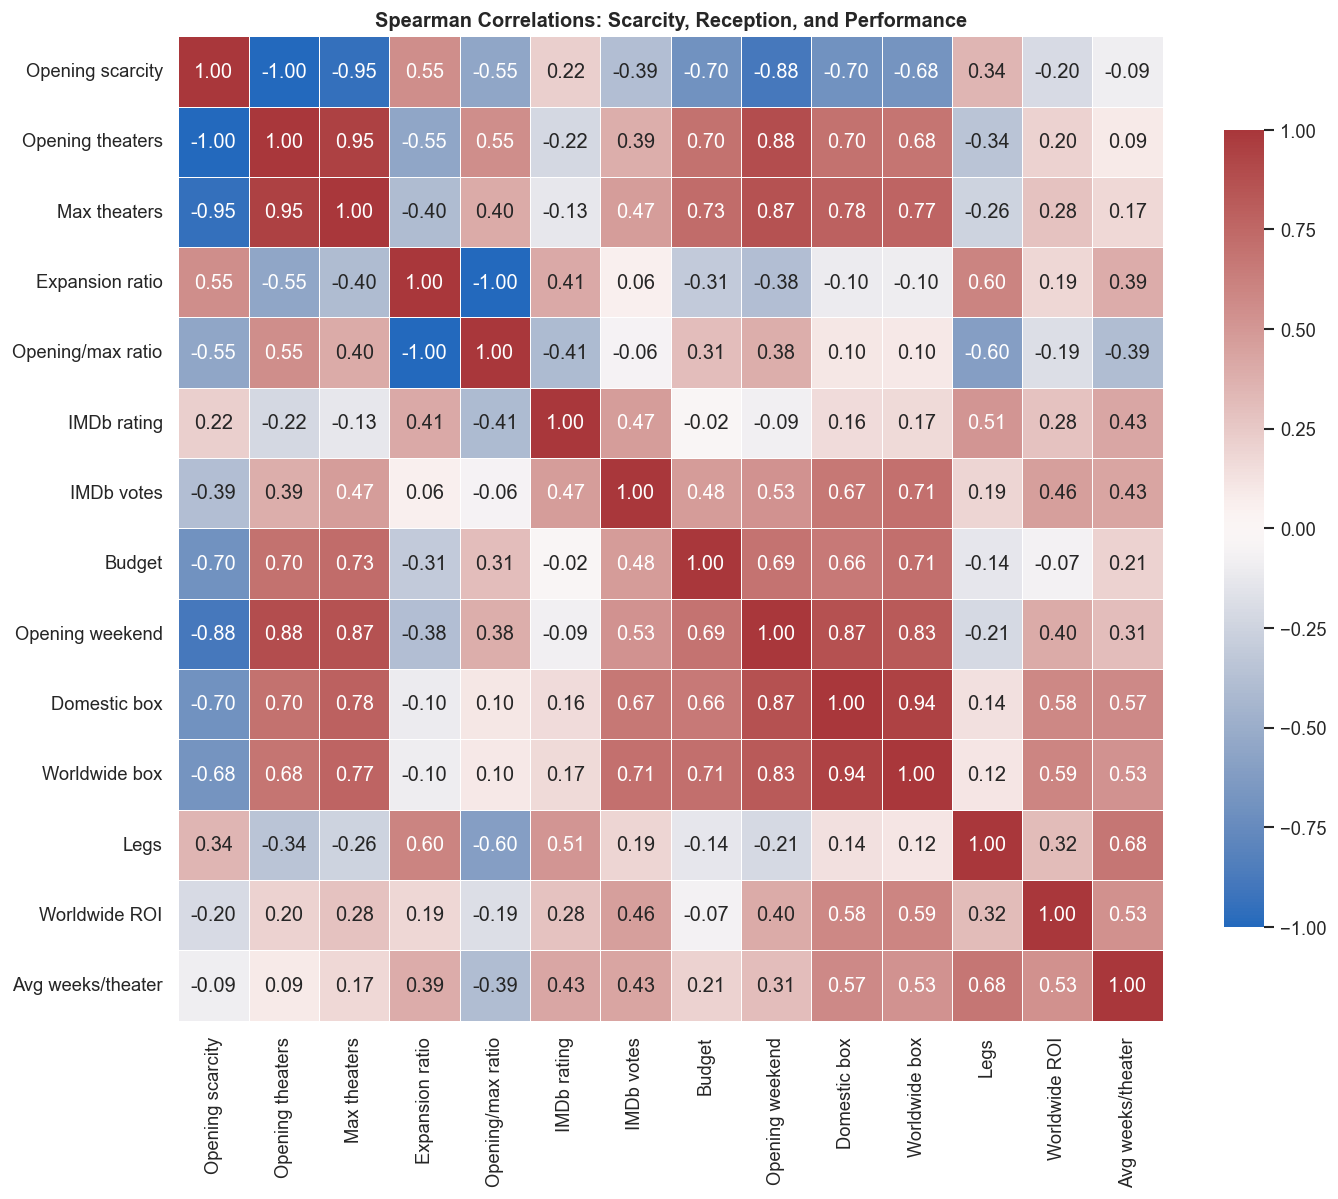

In [15]:
corr_vars = {
    "opening_scarcity_score": "Opening scarcity",
    "opening_theaters": "Opening theaters",
    "max_theaters": "Max theaters",
    "theater_expansion_ratio": "Expansion ratio",
    "opening_to_max_ratio": "Opening/max ratio",
    "imdb_rating_num": "IMDb rating",
    "imdb_votes_num": "IMDb votes",
    "production_budget_usd": "Budget",
    "opening_weekend_usd": "Opening weekend",
    "domestic_box_office_usd": "Domestic box",
    "worldwide_box_office_usd": "Worldwide box",
    "legs": "Legs",
    "roi_worldwide": "Worldwide ROI",
    "avg_weeks_per_theater": "Avg weeks/theater",
}

corr_data = eda[list(corr_vars.keys())].rename(columns=corr_vars)
corr_matrix = corr_data.corr(method="spearman").round(3)
corr_long = corr_matrix.reset_index().rename(columns={"index": "variable"})

save_table(corr_long, "table_18_spearman_correlation_matrix", "Spearman correlation matrix for scarcity, reception, and performance variables.")
display(corr_matrix)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="vlag", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", linewidths=.5, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Spearman Correlations: Scarcity, Reception, and Performance")
plt.tight_layout()
save_figure(fig, "fig_11_correlation_matrix", "Spearman correlation heatmap for core scarcity, reception, and performance variables.")
plt.show()


**Correlation commentary.** Correlation does not identify causality. It is most useful here for checking whether opening scarcity is mostly a proxy for lower budget and smaller revenue, or whether it also connects to expansion, legs, rating, or ROI in ways that support the thesis argument.


## 14. Case-Study Films: Parasite and Oppenheimer

The thesis draft proposes Parasite as a prestige/platform scarcity case and Oppenheimer as a mainstream event-cinema case. This section locates both films in the dataset and compares their measured scarcity profiles.


Saved table: figures/table_19_case_films_parasite_oppenheimer.csv
Saved table: figures/table_19_case_films_parasite_oppenheimer.html


,movie_name,release_year,genre,source,creative_type,positioning_proxy,release_strategy,production_budget_usd,opening_weekend_usd,domestic_box_office_usd,worldwide_box_office_usd,opening_theaters,max_theaters,theater_expansion_ratio,opening_scarcity_percentile,legs,avg_weeks_per_theater,roi_worldwide,imdb_rating_num,imdb_votes_num,opening_theaters_percentile,max_theaters_percentile,expansion_ratio_percentile,legs_percentile,roi_worldwide_percentile,imdb_rating_percentile,worldwide_box_percentile
429,Oppenheimer,2023,Drama,Based on Factual Book/Article,Dramatization,Mainstream/event proxy,"Wide (2,000+)",100000000,"82,455,420.00","329,862,540.00","976,518,442.00","3,610.00","3,761.00",1.04,11.60,4.00,10.10,9.77,8.20,"1,024,033.00",88.40,90.70,68.50,66.30,92.90,98.00,98.70
3032,Parasite (기생충),2019,Black Comedy,Original Screenplay,Contemporary Fiction,Arthouse/prestige proxy,Exclusive (1-10),11800000,"393,216.00","53,369,745.00","253,267,858.00",3.00,"2,001.00",667.00,95.70,9.39,7.20,21.46,8.50,"1,148,210.00",4.30,34.80,99.20,93.10,97.80,99.40,84.70


Saved figure: figures/fig_12_case_films_theater_rollout.png


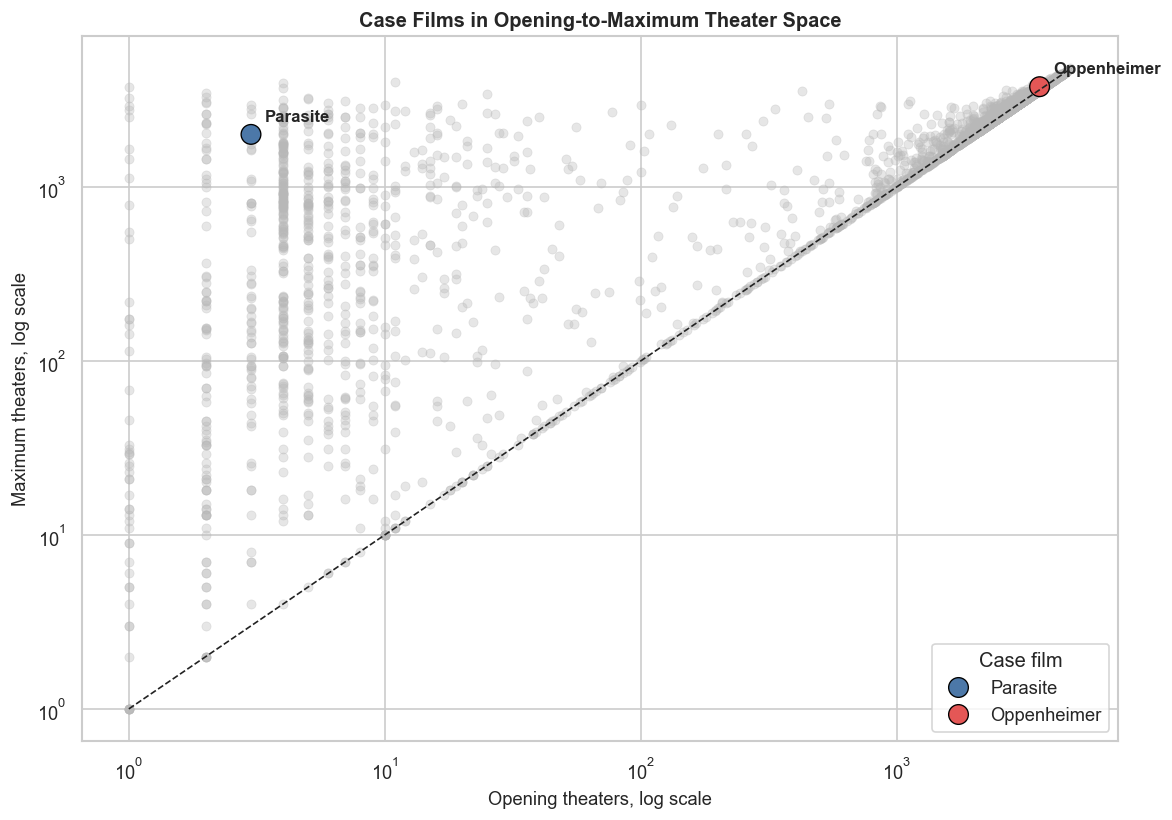

In [16]:
case_mask = eda["movie_name"].str.contains("Parasite|Oppenheimer", case=False, na=False, regex=True)
case_films = eda.loc[case_mask].copy()
case_films["case_label"] = np.where(case_films["movie_name"].str.contains("Parasite", case=False, na=False), "Parasite", "Oppenheimer")

percentile_metrics = {
    "opening_theaters": "opening_theaters_percentile",
    "max_theaters": "max_theaters_percentile",
    "theater_expansion_ratio": "expansion_ratio_percentile",
    "legs": "legs_percentile",
    "roi_worldwide": "roi_worldwide_percentile",
    "imdb_rating_num": "imdb_rating_percentile",
    "worldwide_box_office_usd": "worldwide_box_percentile",
}
for source_col, out_col in percentile_metrics.items():
    ranks = eda[source_col].rank(pct=True) * 100
    case_films[out_col] = ranks.loc[case_films.index].round(1)

case_films["opening_scarcity_percentile"] = case_films["opening_scarcity_pct"].round(1)

case_cols = [
    "movie_name", "release_year", "genre", "source", "creative_type", "positioning_proxy",
    "release_strategy", "production_budget_usd", "opening_weekend_usd", "domestic_box_office_usd",
    "worldwide_box_office_usd", "opening_theaters", "max_theaters", "theater_expansion_ratio",
    "opening_scarcity_percentile", "legs", "avg_weeks_per_theater", "roi_worldwide",
    "imdb_rating_num", "imdb_votes_num", "opening_theaters_percentile", "max_theaters_percentile",
    "expansion_ratio_percentile", "legs_percentile", "roi_worldwide_percentile", "imdb_rating_percentile",
    "worldwide_box_percentile",
]
case_table = case_films[case_cols].sort_values("movie_name").round(2)

save_table(case_table, "table_19_case_films_parasite_oppenheimer", "Dataset profile and percentile ranks for Parasite and Oppenheimer.")
display(case_table)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=eda, x="opening_theaters", y="max_theaters", color="#B8B8B8", alpha=.35, s=30, edgecolor=None, ax=ax)
sns.scatterplot(data=case_films, x="opening_theaters", y="max_theaters", hue="case_label", hue_order=["Parasite", "Oppenheimer"], palette={"Parasite": "#4C78A8", "Oppenheimer": "#E45756"}, s=140, edgecolor="black", linewidth=.8, ax=ax)
for _, row in case_films.iterrows():
    label = row["case_label"]
    ax.annotate(label, (row["opening_theaters"], row["max_theaters"]), xytext=(8, 8), textcoords="offset points", fontsize=10, fontweight="bold")
ax.plot([1, eda["max_theaters"].max()], [1, eda["max_theaters"].max()], color="#222222", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Case Films in Opening-to-Maximum Theater Space")
ax.set_xlabel("Opening theaters, log scale")
ax.set_ylabel("Maximum theaters, log scale")
ax.legend(title="Case film")
plt.tight_layout()
save_figure(fig, "fig_12_case_films_theater_rollout", "Parasite and Oppenheimer compared with the full sample in theater-rollout space.")
plt.show()


**Case-study commentary.** Parasite is measured in this dataset as an extreme platform rollout: very few opening theaters, later expansion to a large footprint, high legs, high IMDb rating, and strong ROI. That fits the thesis argument about scarcity as a prestige-building mechanism. Oppenheimer is measured as a wide release, not a scarce standard theatrical release. Its scarcity story is therefore mostly outside these variables: the dataset cannot observe IMAX 70mm venue scarcity, sell-outs, or premium-format authenticity. Quantitatively, Oppenheimer should be treated as a mainstream/event contrast case rather than as a limited-release case.


## 15. Case-Study-Relevant Films

To support case selection, this section identifies films whose data profile resembles the two thesis models:

- **Parasite-like platform breakouts:** scarce opening, meaningful later expansion, strong IMDb rating, and positive worldwide ROI.
- **Oppenheimer-like mainstream events:** wide opening, high budget or event positioning, strong IMDb rating, strong worldwide box office, and long theatrical life.

These are not replacement cases; they are useful comparison points for the thesis discussion.


In [17]:
parasite_like = (
    eda.loc[
        (eda["opening_theaters"] <= 100)
        & (eda["max_theaters"] >= 500)
        & (eda["imdb_rating_num"] >= 7)
        & (eda["roi_worldwide"] > 1),
        [
            "movie_name", "release_year", "genre", "source", "opening_theaters", "max_theaters",
            "theater_expansion_ratio", "legs", "imdb_rating_num", "worldwide_box_office_usd",
            "roi_worldwide", "positioning_proxy"
        ]
    ]
    .sort_values(["theater_expansion_ratio", "imdb_rating_num"], ascending=False)
    .head(25)
    .round(2)
)

oppenheimer_like = (
    eda.loc[
        (eda["opening_theaters"] >= 2000)
        & (eda["production_budget_usd"] >= budget_q75)
        & (eda["imdb_rating_num"] >= 7)
        & (eda["worldwide_box_office_usd"] >= eda["worldwide_box_office_usd"].quantile(.85))
        & (eda["legs"] >= 3),
        [
            "movie_name", "release_year", "genre", "creative_type", "opening_theaters", "max_theaters",
            "legs", "imdb_rating_num", "production_budget_usd", "worldwide_box_office_usd",
            "roi_worldwide", "positioning_proxy"
        ]
    ]
    .sort_values(["worldwide_box_office_usd", "imdb_rating_num"], ascending=False)
    .head(25)
    .round(2)
)

save_table(parasite_like, "table_20_parasite_like_platform_breakouts", "Films with scarce openings, later expansion, strong IMDb ratings, and positive ROI.")
save_table(oppenheimer_like, "table_21_oppenheimer_like_mainstream_events", "Wide high-budget films with strong ratings, high worldwide box office, and long legs.")

display(Markdown("**Parasite-like platform breakouts**"))
display(parasite_like)
display(Markdown("**Oppenheimer-like mainstream event films**"))
display(oppenheimer_like)


Saved table: figures/table_20_parasite_like_platform_breakouts.csv
Saved table: figures/table_20_parasite_like_platform_breakouts.html
Saved table: figures/table_21_oppenheimer_like_mainstream_events.csv
Saved table: figures/table_21_oppenheimer_like_mainstream_events.html


**Parasite-like platform breakouts**

,movie_name,release_year,genre,source,opening_theaters,max_theaters,theater_expansion_ratio,legs,imdb_rating_num,worldwide_box_office_usd,roi_worldwide,positioning_proxy
209,Frozen,2013,Musical,Based on Folk Tale/Legend/Fairytale,1.00,"3,742.00","3,742.00",5.95,7.40,"1,271,023,300.00",8.47,Mainstream/event proxy
520,Toy Story 2,1999,Adventure,Original Screenplay,1.00,"3,257.00","3,257.00",4.28,7.90,"511,358,276.00",5.68,Mainstream/event proxy
799,Hercules,1997,Adventure,Based on Religious Text,1.00,"2,930.00","2,930.00",4.62,7.30,"250,700,000.00",3.58,Mainstream/event proxy
1308,A Bug’s Life,1998,Adventure,Original Screenplay,1.00,"2,773.00","2,773.00",4.90,7.20,"363,095,319.00",8.07,Arthouse/prestige proxy
1130,Anastasia,1997,Musical,Based on Factual Book/Article,1.00,"2,514.00","2,514.00",4.14,7.20,"139,801,096.00",2.64,Arthouse/prestige proxy
412,The Princess and the Frog,2009,Adventure,Based on Fiction Book/Short Story,2.00,"3,475.00","1,737.50",4.31,7.20,"270,997,378.00",2.58,Mainstream/event proxy
1795,Mr. Holland’s Opus,1995,Drama,Original Screenplay,1.00,"1,659.00","1,659.00",8.92,7.30,"106,282,604.00",3.43,Arthouse/prestige proxy
1428,Lone Survivor,2013,Action,Based on Factual Book/Article,2.00,"3,285.00","1,642.50",3.31,7.30,"149,804,632.00",3.75,Arthouse/prestige proxy
2351,Beauty and the Beast,1991,Musical,Based on Fiction Book/Short Story,2.00,"2,625.00","1,312.50",11.62,8.00,"438,656,843.00",21.93,Mainstream/event proxy
696,The Lion King,1994,Adventure,Original Screenplay,2.00,"2,624.00","1,312.00",10.37,8.50,"988,389,726.00",12.46,Mainstream/event proxy


**Oppenheimer-like mainstream event films**

,movie_name,release_year,genre,creative_type,opening_theaters,max_theaters,legs,imdb_rating_num,production_budget_usd,worldwide_box_office_usd,roi_worldwide,positioning_proxy
31,Avatar,2009,Action,Science Fiction,"3,452.00","3,461.00",10.19,7.90,237000000,"2,923,706,026.00",12.34,Mainstream/event proxy
0,Avatar: The Way of Water,2022,Action,Science Fiction,"4,202.00","4,340.00",5.10,7.50,460000000,"2,315,589,775.00",5.03,Mainstream/event proxy
56,Titanic,1997,Drama,Historical Fiction,"2,674.00","3,265.00",19.02,8.00,200000000,"2,223,048,786.00",11.12,Mainstream/event proxy
54,Spider-Man: No Way Home,2021,Action,Super Hero,"4,336.00","4,336.00",3.13,8.10,200000000,"1,921,206,586.00",9.61,Mainstream/event proxy
57,Inside Out 2,2024,Adventure,Kids Fiction,"4,440.00","4,440.00",4.23,7.50,200000000,"1,698,863,816.00",8.49,Mainstream/event proxy
36,The Avengers,2012,Action,Super Hero,"4,349.00","4,349.00",3.01,8.00,225000000,"1,515,100,211.00",6.73,Mainstream/event proxy
157,Top Gun: Maverick,2022,Action,Contemporary Fiction,"4,735.00","4,751.00",5.67,8.20,170000000,"1,455,073,504.00",8.56,Mainstream/event proxy
426,The Super Mario Bros. Movie,2023,Adventure,Kids Fiction,"4,343.00","4,371.00",3.93,7.00,100000000,"1,359,146,628.00",13.59,Mainstream/event proxy
58,Deadpool & Wolverine,2024,Action,Super Hero,"4,210.00","4,330.00",3.01,7.50,200000000,"1,338,071,348.00",6.69,Mainstream/event proxy
55,Black Panther,2018,Action,Super Hero,"4,020.00","4,084.00",3.47,7.30,200000000,"1,334,157,082.00",6.67,Mainstream/event proxy


**Comparison-film commentary.** Parasite-like films are the best quantitative candidates for studying scarcity as artistic distinction because they begin with restricted access and later gain broader recognition. Oppenheimer-like films are better for studying event scarcity, where the film itself is widely available but the most valued version, format, or moment is scarce. The second mechanism needs external premium-format data.


## 16. Final Analysis and Research Questions

The EDA gives a quantitative map of release scarcity, but it does not fully answer the symbolic and interpretive parts of the thesis. The table below separates what this dataset can answer from what requires qualitative case evidence, industry sources, audience discourse, festival history, ticketing data, or premium-format data.


In [18]:
research_questions = pd.DataFrame([
    {"research_question": "Main RQ: Under what conditions does scarcity operate as symbolic value rather than only access constraint?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "The strongest measurable condition is a scarce opening combined with later expansion, strong reception, long legs, and/or efficient ROI. This pattern fits platform prestige releases more than ordinary low-access films.", "not_answered_by_this_dataset": "Audience interpretation, marketing language, festival legitimation, social distinction, and whether viewers saw scarcity as prestige rather than inconvenience."},
    {"research_question": "Does scarcity in cinema function as a symbolic signal of artistic value and social distinction?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "Scarce/platform films can be identified and compared with IMDb ratings, expansion, legs, and ROI. Parasite's measured profile supports the plausibility of scarcity as a prestige signal.", "not_answered_by_this_dataset": "The dataset cannot observe symbolic meaning directly; it only observes outcomes and release structure."},
    {"research_question": "What forms of scarcity are most relevant in cinema?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "The measurable forms are initial theater scarcity, limited release strategy, platform expansion, opening-to-maximum theater restriction, and limited theatrical staying power.", "not_answered_by_this_dataset": "Festival-only circulation, one-night screenings, sold-out screenings, members-only previews, delayed streaming, 70mm/IMAX scarcity, and invitation-only premieres."},
    {"research_question": "How is scarcity communicated by cinemas, festivals, distributors, and marketers?", "eda_answer_status": "Not answered", "answer_from_this_dataset": "The dataset has no marketing text, festival programming, trailer language, press strategy, ticketing pages, or distributor communication.", "not_answered_by_this_dataset": "Requires qualitative content analysis and industry/case sources."},
    {"research_question": "When do audiences interpret scarcity as prestige rather than inconvenience?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "A plausible indicator is scarce opening plus high IMDb rating, high votes, long legs, and expansion. Those conditions imply that restricted access did not prevent positive reception.", "not_answered_by_this_dataset": "Actual interpretation requires audience reviews, social media discourse, surveys, interviews, or press reception."},
    {"research_question": "Does scarcity work differently for arthouse, festival, and mainstream films?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "Proxy comparisons show that platform/prestige films and mainstream/event films have different release structures. Parasite is measured as platform scarcity; Oppenheimer is measured as wide release.", "not_answered_by_this_dataset": "Festival status and premium-format scarcity are not directly measured."},
    {"research_question": "Does scarcity in arthouse and festival cinema signal artistic legitimacy and distinction?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "For prestige proxies, scarce openings with expansion and strong IMDb ratings are consistent with artistic-legitimacy signaling.", "not_answered_by_this_dataset": "Awards, festival selection, critic discourse, and cultural-capital interpretation are outside the file."},
    {"research_question": "How do limited screenings and premium formats turn films into scarce cultural events?", "eda_answer_status": "Mostly not answered", "answer_from_this_dataset": "The limited-release part can be studied through opening theaters and expansion. Oppenheimer's wide-release record shows the dataset does not capture premium-format scarcity.", "not_answered_by_this_dataset": "Requires IMAX/70mm venue counts, sold-out ticket data, showtime data, premium-format pricing, and press/social-media evidence."},
    {"research_question": "Why does scarcity create prestige for some films but not for mainstream blockbusters?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "The data suggests different mechanisms: platform scarcity for prestige films versus event/premium scarcity for mainstream films. Scarce opening alone is insufficient; it needs quality signals, expansion, and audience validation.", "not_answered_by_this_dataset": "The causal reason requires case interpretation and theory, especially Bourdieu, authenticity, FOMO, and distributor strategy."},
    {"research_question": "What are the managerial implications for distributors and exhibitors?", "eda_answer_status": "Partially answered", "answer_from_this_dataset": "The EDA suggests controlled openings can be useful when the film has prestige markers, positive reception, and expansion potential; wide/event releases need different scarcity levers such as premium formats or exclusive windows.", "not_answered_by_this_dataset": "Profit-sharing, marketing spend, ticket prices, exhibitor contracts, screen allocation, and operational constraints are not measured."},
])

save_table(research_questions, "table_22_research_questions_answer_status", "Research questions mapped to what the EDA can and cannot answer.")
display(research_questions)


Saved table: figures/table_22_research_questions_answer_status.csv
Saved table: figures/table_22_research_questions_answer_status.html


,research_question,eda_answer_status,answer_from_this_dataset,not_answered_by_this_dataset
0,Main RQ: Under what conditions does scarcity o...,Partially answered,The strongest measurable condition is a scarce...,"Audience interpretation, marketing language, f..."
1,Does scarcity in cinema function as a symbolic...,Partially answered,Scarce/platform films can be identified and co...,The dataset cannot observe symbolic meaning di...
2,What forms of scarcity are most relevant in ci...,Partially answered,The measurable forms are initial theater scarc...,"Festival-only circulation, one-night screening..."
3,"How is scarcity communicated by cinemas, festi...",Not answered,"The dataset has no marketing text, festival pr...",Requires qualitative content analysis and indu...
4,When do audiences interpret scarcity as presti...,Partially answered,A plausible indicator is scarce opening plus h...,Actual interpretation requires audience review...
5,"Does scarcity work differently for arthouse, f...",Partially answered,Proxy comparisons show that platform/prestige ...,Festival status and premium-format scarcity ar...
6,Does scarcity in arthouse and festival cinema ...,Partially answered,"For prestige proxies, scarce openings with exp...","Awards, festival selection, critic discourse, ..."
7,How do limited screenings and premium formats ...,Mostly not answered,The limited-release part can be studied throug...,"Requires IMAX/70mm venue counts, sold-out tick..."
8,Why does scarcity create prestige for some fil...,Partially answered,The data suggests different mechanisms: platfo...,The causal reason requires case interpretation...
9,What are the managerial implications for distr...,Partially answered,The EDA suggests controlled openings can be us...,"Profit-sharing, marketing spend, ticket prices..."


### Final Thesis Takeaways

1. **The dataset supports a measurable distinction between access scarcity and symbolic-scarcity candidates.** The latter are not merely small releases; they are films that begin scarce and then show expansion, strong reception, long legs, or efficient ROI.

2. **Parasite is the clean quantitative fit for platform scarcity.** Its theater rollout shows restricted initial access followed by major expansion, which matches the thesis framing of scarcity as prestige-building and artistic legitimation.

3. **Oppenheimer is not scarce in ordinary theater-count terms.** Its relevance comes from premium-format and temporal scarcity, especially IMAX 70mm access. That means the Oppenheimer case needs external data beyond this CSV.

4. **IMDb rating, legs, and ROI are supporting evidence, not direct measures of symbolic value.** They help identify films where scarcity plausibly worked as more than access constraint, but they cannot prove social distinction or audience interpretation.

5. **The thesis should combine this EDA with qualitative case evidence.** The quantitative analysis can justify case selection and describe rollout patterns; the thesis argument about prestige, authenticity, FOMO, and cultural distinction requires case documents, press coverage, festival/awards histories, and audience discourse.


In [19]:
artifact_index = pd.DataFrame(artifact_records)
artifact_index_path = FIGURES_DIR / "table_99_eda_artifact_index.csv"
artifact_index_html_path = FIGURES_DIR / "table_99_eda_artifact_index.html"
artifact_index.to_csv(artifact_index_path, index=False)
artifact_index.to_html(artifact_index_html_path, index=False, border=0)
print(f"Saved artifact index: {rel(artifact_index_path)}")
print(f"Saved artifact index: {rel(artifact_index_html_path)}")
display(artifact_index)


Saved artifact index: figures/table_99_eda_artifact_index.csv
Saved artifact index: figures/table_99_eda_artifact_index.html


,artifact,type,description
0,figures/table_01_data_quality_columns.csv,table_csv,"Column-level missingness, dtypes, and unique-v..."
1,figures/table_01_data_quality_columns.html,table_html,"Column-level missingness, dtypes, and unique-v..."
2,figures/table_02_data_quality_checks.csv,table_csv,Dataset-level data quality checks for the EDA ...
3,figures/table_02_data_quality_checks.html,table_html,Dataset-level data quality checks for the EDA ...
4,figures/table_03_numeric_summary.csv,table_csv,Descriptive summary for the main numeric varia...
5,figures/table_03_numeric_summary.html,table_html,Descriptive summary for the main numeric varia...
6,figures/table_04_scarcity_variable_dictionary.csv,table_csv,Definitions of constructed scarcity and positi...
7,figures/table_04_scarcity_variable_dictionary....,table_html,Definitions of constructed scarcity and positi...
8,figures/table_05_release_strategy_summary.csv,table_csv,Film counts and median outcomes by release-str...
9,figures/table_05_release_strategy_summary.html,table_html,Film counts and median outcomes by release-str...
